In [1]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 1 - Imports and Experiment Setup
# ==========================================================

# Bu notebook'un amacı:
#
# 1) Daha önce oluşturduğumuz Mouth ROI görüntülerini okumak.
# 2) Xception ile deep feature extraction yapmak.
# 3) Real / Fake sınıflandırması yapmak.
# 4) Accuracy, Precision, Recall, F1 ve AUC hesaplamak.
# 5) Confusion Matrix ve ROC Curve üretmek.
#
# NOT:
# Bu notebook Mouth ROI üretmez.
# ROI üretme aşaması önceki notebook'ta tamamlandı.


# ==========================================================
# 1. GEREKLİ KÜTÜPHANELER
# ==========================================================

import os
import json
import time
import random

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


# ==========================================================
# 2. XCEPTION
# ==========================================================

# ImageNet üzerinde önceden eğitilmiş
# Xception backbone'unu kullanacağız.

from tensorflow.keras.applications import Xception

# Xception'ın beklediği görüntü normalizasyonu.
from tensorflow.keras.applications.xception import preprocess_input


# ==========================================================
# 3. MODEL DEĞERLENDİRME KÜTÜPHANELERİ
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ==========================================================
# 4. RANDOM SEED
# ==========================================================
#
# Deneyin mümkün olduğunca tekrar üretilebilir olması için
# Python, NumPy ve TensorFlow seed değerlerini sabitliyoruz.

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)


# ==========================================================
# 5. TENSORFLOW SÜRÜMÜ
# ==========================================================

print("=" * 70)
print("XCEPTION EXPERIMENT - ENVIRONMENT CHECK")
print("=" * 70)

print(
    f"\nTensorFlow sürümü: "
    f"{tf.__version__}"
)


# ==========================================================
# 6. GPU KONTROLÜ
# ==========================================================

gpu_devices = tf.config.list_physical_devices(
    "GPU"
)


print(
    "\nBulunan GPU cihazları:"
)

print(
    gpu_devices
)


if len(gpu_devices) > 0:

    print(
        "\n✓ GPU kullanılabilir."
    )

else:

    print(
        "\n⚠ GPU bulunamadı."
    )

    print(
        "Colab > Runtime > Change runtime type > GPU "
        "seçmen önerilir."
    )


# ==========================================================
# 7. TEMEL DENEY PARAMETRELERİ
# ==========================================================

# Mouth ROI görüntülerimiz 224x224.
IMG_HEIGHT = 224

IMG_WIDTH = 224

IMG_SIZE = (
    IMG_HEIGHT,
    IMG_WIDTH
)


# İlk deneme için batch size.
# GPU belleğine göre daha sonra 32 yapılabilir.
BATCH_SIZE = 16


# Binary classification:
#
# 0 -> REAL
# 1 -> FAKE

CLASS_NAMES = [
    "real",
    "fake"
]


print("\n" + "=" * 70)
print("EXPERIMENT CONFIGURATION")
print("=" * 70)

print(
    f"Random seed : {SEED}"
)

print(
    f"Image size  : {IMG_WIDTH} x {IMG_HEIGHT}"
)

print(
    f"Batch size  : {BATCH_SIZE}"
)

print(
    f"Classes     : {CLASS_NAMES}"
)


# ==========================================================
# 8. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)

print(
    "✓ CELL 1 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ TensorFlow / Keras hazır."
)

print(
    "✓ Xception import edildi."
)

print(
    "✓ Değerlendirme metrikleri hazır."
)

print(
    "✓ Random seed sabitlendi."
)

print("=" * 70)

XCEPTION EXPERIMENT - ENVIRONMENT CHECK

TensorFlow sürümü: 2.20.0

Bulunan GPU cihazları:
[]

⚠ GPU bulunamadı.
Colab > Runtime > Change runtime type > GPU seçmen önerilir.

EXPERIMENT CONFIGURATION
Random seed : 42
Image size  : 224 x 224
Batch size  : 16
Classes     : ['real', 'fake']

✓ CELL 1 BAŞARIYLA TAMAMLANDI
✓ TensorFlow / Keras hazır.
✓ Xception import edildi.
✓ Değerlendirme metrikleri hazır.
✓ Random seed sabitlendi.


In [2]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 2 - Google Drive and Dataset Paths
# ==========================================================

# Bu hücre:
#
# 1) Google Drive'ı Colab'a bağlar.
# 2) Önceki notebook'ta oluşturduğumuz Mouth ROI datasetinin
#    yolunu tanımlar.
# 3) Xception deney sonuçlarının kaydedileceği ayrı bir
#    klasör oluşturur.
# 4) Kritik klasörlerin gerçekten mevcut olup olmadığını
#    kontrol eder.
#
# ÖNEMLİ:
# mouth_roi_output içerisindeki ROI görüntüleri
# değiştirilmez veya yeniden oluşturulmaz.


# ==========================================================
# 1. GOOGLE DRIVE
# ==========================================================

from google.colab import drive

print("=" * 70)
print("GOOGLE DRIVE BAĞLANTISI")
print("=" * 70)

drive.mount(
    "/content/drive",
    force_remount=False
)

print(
    "\n✓ Google Drive bağlantısı hazır."
)


# ==========================================================
# 2. PROJE ANA KLASÖRÜ
# ==========================================================
#
# Önceki notebook'ta kesinleştirdiğimiz gerçek Drive yolu:
#
# AISC Çalışmalar
# └── Deneyler
#     └── Dilara
#         └── Deney 1
#             └── Ağız


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "AISC Çalışmalar/"
    "Deneyler/"
    "Dilara/"
    "Deney 1/"
    "Ağız"
)


# ==========================================================
# 3. MOUTH ROI DATASET
# ==========================================================
#
# Daha önce oluşturduğumuz yapı:
#
# mouth_roi_output/
#
# ├── fake/
# │   ├── train/mouth
# │   ├── val/mouth
# │   └── test/mouth
# │
# └── real/
#     ├── train/mouth
#     ├── val/mouth
#     └── test/mouth


MOUTH_ROI_ROOT = (
    PROJECT_ROOT
    / "mouth_roi_output"
)


# ==========================================================
# 4. TRAIN KLASÖRLERİ
# ==========================================================

FAKE_TRAIN_DIR = (
    MOUTH_ROI_ROOT
    / "fake"
    / "train"
    / "mouth"
)


REAL_TRAIN_DIR = (
    MOUTH_ROI_ROOT
    / "real"
    / "train"
    / "mouth"
)


# ==========================================================
# 5. VALIDATION KLASÖRLERİ
# ==========================================================

FAKE_VAL_DIR = (
    MOUTH_ROI_ROOT
    / "fake"
    / "val"
    / "mouth"
)


REAL_VAL_DIR = (
    MOUTH_ROI_ROOT
    / "real"
    / "val"
    / "mouth"
)


# ==========================================================
# 6. TEST KLASÖRLERİ
# ==========================================================

FAKE_TEST_DIR = (
    MOUTH_ROI_ROOT
    / "fake"
    / "test"
    / "mouth"
)


REAL_TEST_DIR = (
    MOUTH_ROI_ROOT
    / "real"
    / "test"
    / "mouth"
)


# ==========================================================
# 7. XCEPTION DENEY ÇIKTI KLASÖRÜ
# ==========================================================
#
# Model, grafik ve metrikleri Mouth ROI datasetinin içine
# karıştırmıyoruz.
#
# Ayrı bir klasör oluşturuyoruz:


EXPERIMENT_ROOT = (
    PROJECT_ROOT
    / "xception_experiment"
)


EXPERIMENT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# Model dosyaları
MODEL_DIR = (
    EXPERIMENT_ROOT
    / "models"
)


# Grafikler
PLOTS_DIR = (
    EXPERIMENT_ROOT
    / "plots"
)


# Metrikler / CSV / JSON
RESULTS_DIR = (
    EXPERIMENT_ROOT
    / "results"
)


MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ==========================================================
# 8. KRİTİK KLASÖR KONTROLÜ
# ==========================================================

dataset_paths = {

    "Fake Train":
        FAKE_TRAIN_DIR,

    "Real Train":
        REAL_TRAIN_DIR,

    "Fake Val":
        FAKE_VAL_DIR,

    "Real Val":
        REAL_VAL_DIR,

    "Fake Test":
        FAKE_TEST_DIR,

    "Real Test":
        REAL_TEST_DIR
}


print(
    "\n"
    + "=" * 70
)

print(
    "MOUTH ROI DATASET YOL KONTROLÜ"
)

print(
    "=" * 70
)


all_paths_valid = True


for name, path in dataset_paths.items():

    exists = path.exists()

    print(
        f"{name:<15}: "
        f"{exists}"
    )

    print(
        f"    {path}"
    )


    if not exists:

        all_paths_valid = False


# ==========================================================
# 9. PROJECT ROOT KONTROLÜ
# ==========================================================

print(
    "\nProject root mevcut mu? :",
    PROJECT_ROOT.exists()
)


print(
    "Mouth ROI root mevcut mu?:",
    MOUTH_ROI_ROOT.exists()
)


print(
    "Experiment root         :",
    EXPERIMENT_ROOT
)


# ==========================================================
# 10. KRİTİK HATA KONTROLÜ
# ==========================================================

if not PROJECT_ROOT.exists():

    raise FileNotFoundError(
        "PROJECT_ROOT bulunamadı."
    )


if not MOUTH_ROI_ROOT.exists():

    raise FileNotFoundError(
        "mouth_roi_output klasörü bulunamadı."
    )


if not all_paths_valid:

    raise FileNotFoundError(
        "Fake/Real Train/Val/Test Mouth klasörlerinden "
        "en az biri bulunamadı."
    )


# ==========================================================
# 11. CELL SONUCU
# ==========================================================

print(
    "\n"
    + "=" * 70
)

print(
    "✓ CELL 2 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ Mouth ROI dataseti bulundu."
)

print(
    "✓ Fake / Real yolları bulundu."
)

print(
    "✓ Train / Val / Test yolları bulundu."
)

print(
    "✓ Xception deney klasörleri hazır."
)

print(
    "=" * 70
)

GOOGLE DRIVE BAĞLANTISI
Mounted at /content/drive

✓ Google Drive bağlantısı hazır.

MOUTH ROI DATASET YOL KONTROLÜ
Fake Train     : True
    /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/train/mouth
Real Train     : True
    /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/real/train/mouth
Fake Val       : True
    /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/val/mouth
Real Val       : True
    /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/real/val/mouth
Fake Test      : True
    /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/test/mouth
Real Test      : True
    /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/real/test/mouth

Project root mevcut mu? : True
Mouth ROI root mevcut mu?: True
Experiment root         : /content/drive

In [3]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 3 - Dataset Count and Class Balance Check
# ==========================================================

# Bu hücre:
#
# 1) Fake / Real klasörlerindeki Mouth ROI görüntülerini sayar.
# 2) Train / Val / Test toplamlarını hesaplar.
# 3) Sınıf dağılımını kontrol eder.
# 4) Beklenmedik dengesizlik varsa uyarı verir.
#
# Henüz model eğitimi başlamaz.


print("=" * 70)
print("XCEPTION DATASET COUNT & CLASS BALANCE CHECK")
print("=" * 70)


# ==========================================================
# 1. DESTEKLENEN GÖRÜNTÜ UZANTILARI
# ==========================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


# ==========================================================
# 2. GÖRÜNTÜ SAYMA FONKSİYONU
# ==========================================================

def count_images(folder):
    """
    Verilen klasör içerisindeki görüntü dosyalarını sayar.
    """

    folder = Path(folder)

    if not folder.exists():
        return 0

    count = 0

    for file_path in folder.iterdir():

        if (
            file_path.is_file()
            and
            file_path.suffix.lower() in IMAGE_EXTENSIONS
        ):
            count += 1

    return count


# ==========================================================
# 3. TÜM KLASÖRLERDEKİ ROI SAYILARINI HESAPLA
# ==========================================================

dataset_counts = {

    "fake_train": count_images(
        FAKE_TRAIN_DIR
    ),

    "real_train": count_images(
        REAL_TRAIN_DIR
    ),

    "fake_val": count_images(
        FAKE_VAL_DIR
    ),

    "real_val": count_images(
        REAL_VAL_DIR
    ),

    "fake_test": count_images(
        FAKE_TEST_DIR
    ),

    "real_test": count_images(
        REAL_TEST_DIR
    )
}


# ==========================================================
# 4. SONUÇLARI YAZDIR
# ==========================================================

print("\n" + "=" * 70)
print("MOUTH ROI SAYILARI")
print("=" * 70)

for key, value in dataset_counts.items():

    print(
        f"{key:<15}: "
        f"{value}"
    )


# ==========================================================
# 5. SPLIT TOPLAMLARI
# ==========================================================

TRAIN_TOTAL = (
    dataset_counts["fake_train"]
    +
    dataset_counts["real_train"]
)


VAL_TOTAL = (
    dataset_counts["fake_val"]
    +
    dataset_counts["real_val"]
)


TEST_TOTAL = (
    dataset_counts["fake_test"]
    +
    dataset_counts["real_test"]
)


TOTAL_ROI = (
    TRAIN_TOTAL
    +
    VAL_TOTAL
    +
    TEST_TOTAL
)


print("\n" + "=" * 70)
print("SPLIT TOPLAMLARI")
print("=" * 70)


print(
    f"Train toplam : "
    f"{TRAIN_TOTAL}"
)


print(
    f"Val toplam   : "
    f"{VAL_TOTAL}"
)


print(
    f"Test toplam  : "
    f"{TEST_TOTAL}"
)


print(
    f"\nGenel toplam : "
    f"{TOTAL_ROI}"
)


# ==========================================================
# 6. SINIF DENGESİ
# ==========================================================

print("\n" + "=" * 70)
print("SINIF DENGESİ")
print("=" * 70)


print(
    "TRAIN -> "
    f"Fake: {dataset_counts['fake_train']} | "
    f"Real: {dataset_counts['real_train']}"
)


print(
    "VAL   -> "
    f"Fake: {dataset_counts['fake_val']} | "
    f"Real: {dataset_counts['real_val']}"
)


print(
    "TEST  -> "
    f"Fake: {dataset_counts['fake_test']} | "
    f"Real: {dataset_counts['real_test']}"
)


# ==========================================================
# 7. ORANLARI HESAPLA
# ==========================================================

def class_ratio(fake_count, real_count):
    """
    Fake / Real oranlarını yüzde olarak döndürür.
    """

    total = fake_count + real_count

    if total == 0:
        return 0.0, 0.0

    fake_ratio = (
        fake_count / total
    ) * 100

    real_ratio = (
        real_count / total
    ) * 100

    return fake_ratio, real_ratio


train_fake_ratio, train_real_ratio = class_ratio(
    dataset_counts["fake_train"],
    dataset_counts["real_train"]
)


val_fake_ratio, val_real_ratio = class_ratio(
    dataset_counts["fake_val"],
    dataset_counts["real_val"]
)


test_fake_ratio, test_real_ratio = class_ratio(
    dataset_counts["fake_test"],
    dataset_counts["real_test"]
)


print("\nYüzdesel dağılım:")


print(
    f"Train -> "
    f"Fake %{train_fake_ratio:.2f} | "
    f"Real %{train_real_ratio:.2f}"
)


print(
    f"Val   -> "
    f"Fake %{val_fake_ratio:.2f} | "
    f"Real %{val_real_ratio:.2f}"
)


print(
    f"Test  -> "
    f"Fake %{test_fake_ratio:.2f} | "
    f"Real %{test_real_ratio:.2f}"
)


# ==========================================================
# 8. TEMEL DENGE KONTROLÜ
# ==========================================================

def check_balance(fake_count, real_count, split_name):
    """
    İki sınıf arasında ciddi dengesizlik olup olmadığını
    kaba şekilde kontrol eder.
    """

    total = fake_count + real_count

    if total == 0:

        print(
            f"⚠ {split_name}: Veri bulunamadı."
        )

        return


    difference_ratio = abs(
        fake_count - real_count
    ) / total


    # %10'dan fazla fark varsa uyar.
    if difference_ratio > 0.10:

        print(
            f"⚠ {split_name}: "
            f"Sınıf dengesizliği olabilir."
        )

    else:

        print(
            f"✓ {split_name}: "
            f"Sınıf dağılımı dengeli."
        )


print("\n" + "=" * 70)
print("DENGE KONTROLÜ")
print("=" * 70)


check_balance(
    dataset_counts["fake_train"],
    dataset_counts["real_train"],
    "TRAIN"
)


check_balance(
    dataset_counts["fake_val"],
    dataset_counts["real_val"],
    "VAL"
)


check_balance(
    dataset_counts["fake_test"],
    dataset_counts["real_test"],
    "TEST"
)


# ==========================================================
# 9. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)

print(
    "✓ CELL 3 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ Mouth ROI sayıları hesaplandı."
)

print(
    "✓ Train / Val / Test dağılımı kontrol edildi."
)

print(
    "✓ Fake / Real sınıf dengesi kontrol edildi."
)

print(
    "✓ Henüz model eğitimi başlamadı."
)

print("=" * 70)

XCEPTION DATASET COUNT & CLASS BALANCE CHECK

MOUTH ROI SAYILARI
fake_train     : 1192
real_train     : 1197
fake_val       : 141
real_val       : 155
fake_test      : 156
real_test      : 146

SPLIT TOPLAMLARI
Train toplam : 2389
Val toplam   : 296
Test toplam  : 302

Genel toplam : 2987

SINIF DENGESİ
TRAIN -> Fake: 1192 | Real: 1197
VAL   -> Fake: 141 | Real: 155
TEST  -> Fake: 156 | Real: 146

Yüzdesel dağılım:
Train -> Fake %49.90 | Real %50.10
Val   -> Fake %47.64 | Real %52.36
Test  -> Fake %51.66 | Real %48.34

DENGE KONTROLÜ
✓ TRAIN: Sınıf dağılımı dengeli.
✓ VAL: Sınıf dağılımı dengeli.
✓ TEST: Sınıf dağılımı dengeli.

✓ CELL 3 BAŞARIYLA TAMAMLANDI
✓ Mouth ROI sayıları hesaplandı.
✓ Train / Val / Test dağılımı kontrol edildi.
✓ Fake / Real sınıf dengesi kontrol edildi.
✓ Henüz model eğitimi başlamadı.


In [4]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 4 - TensorFlow Data Pipeline
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Train / Validation / Test Mouth ROI dosyalarını bulmak.
# 2) Her görüntüye doğru etiketi vermek:
#
#       REAL -> 0
#       FAKE -> 1
#
# 3) Dosya yollarını TensorFlow Dataset yapısına çevirmek.
# 4) Görüntüleri okumak ve RGB formatına dönüştürmek.
# 5) Görüntü boyutunu 224x224 olarak garanti etmek.
# 6) Dataset'i batch'lere ayırmak.
# 7) Train datasetini shuffle etmek.
#
# ÖNEMLİ:
#
# Bu hücrede henüz:
#
# - Data augmentation yapılmıyor.
# - Xception preprocess_input uygulanmıyor.
# - Model oluşturulmuyor.
# - Eğitim başlamıyor.
#
# Bunları sonraki hücrelerde ayrı ayrı yapacağız.
# ==========================================================


print("=" * 70)
print("XCEPTION - TENSORFLOW DATA PIPELINE")
print("=" * 70)


# ==========================================================
# 1. GÖRÜNTÜ DOSYALARINI TOPLAMA FONKSİYONU
# ==========================================================

def get_image_files(folder):
    """
    Belirtilen klasörde bulunan desteklenen
    görüntü dosyalarının yollarını döndürür.

    Dosyalar sorted() ile sıralanır.
    Böylece deney yapısı daha kontrollü olur.
    """

    folder = Path(folder)

    files = []

    for file_path in folder.iterdir():

        if (
            file_path.is_file()
            and
            file_path.suffix.lower() in IMAGE_EXTENSIONS
        ):

            files.append(
                str(file_path)
            )

    return sorted(files)


# ==========================================================
# 2. TRAIN DOSYALARINI TOPLA
# ==========================================================

real_train_files = get_image_files(
    REAL_TRAIN_DIR
)

fake_train_files = get_image_files(
    FAKE_TRAIN_DIR
)


# ==========================================================
# 3. VALIDATION DOSYALARINI TOPLA
# ==========================================================

real_val_files = get_image_files(
    REAL_VAL_DIR
)

fake_val_files = get_image_files(
    FAKE_VAL_DIR
)


# ==========================================================
# 4. TEST DOSYALARINI TOPLA
# ==========================================================

real_test_files = get_image_files(
    REAL_TEST_DIR
)

fake_test_files = get_image_files(
    FAKE_TEST_DIR
)


# ==========================================================
# 5. ETİKETLERİ OLUŞTUR
# ==========================================================
#
# Binary classification:
#
# REAL = 0
# FAKE = 1
#
# Bu eşlemeyi deney boyunca ASLA değiştirmiyoruz.


real_train_labels = [
    0
] * len(real_train_files)

fake_train_labels = [
    1
] * len(fake_train_files)


real_val_labels = [
    0
] * len(real_val_files)

fake_val_labels = [
    1
] * len(fake_val_files)


real_test_labels = [
    0
] * len(real_test_files)

fake_test_labels = [
    1
] * len(fake_test_files)


# ==========================================================
# 6. REAL + FAKE DOSYALARINI BİRLEŞTİR
# ==========================================================

train_files = (
    real_train_files
    +
    fake_train_files
)

train_labels = (
    real_train_labels
    +
    fake_train_labels
)


val_files = (
    real_val_files
    +
    fake_val_files
)

val_labels = (
    real_val_labels
    +
    fake_val_labels
)


test_files = (
    real_test_files
    +
    fake_test_files
)

test_labels = (
    real_test_labels
    +
    fake_test_labels
)


# ==========================================================
# 7. SAYILARI KONTROL ET
# ==========================================================

print("\nDosya sayıları:")

print(
    f"Train : {len(train_files)}"
)

print(
    f"Val   : {len(val_files)}"
)

print(
    f"Test  : {len(test_files)}"
)


# Önceki Cell ile aynı olması gerekir.

assert len(train_files) == TRAIN_TOTAL, (
    "Train dosya sayısı Cell 3 ile uyuşmuyor."
)

assert len(val_files) == VAL_TOTAL, (
    "Validation dosya sayısı Cell 3 ile uyuşmuyor."
)

assert len(test_files) == TEST_TOTAL, (
    "Test dosya sayısı Cell 3 ile uyuşmuyor."
)


print(
    "\n✓ Dosya sayıları Cell 3 sonuçlarıyla uyumlu."
)


# ==========================================================
# 8. GÖRÜNTÜ OKUMA FONKSİYONU
# ==========================================================

def load_image(image_path, label):
    """
    Görüntüyü diskten okur ve model için hazırlar.

    İşlemler:

    1) Dosya okunur.
    2) JPEG/PNG otomatik decode edilir.
    3) RGB -> 3 kanal garanti edilir.
    4) 224x224 boyutuna getirilir.
    5) float32 veri tipine çevrilir.

    NOT:
    Xception preprocess_input henüz burada uygulanmıyor.
    """

    # Dosyayı binary olarak oku.
    image = tf.io.read_file(
        image_path
    )


    # JPEG / PNG gibi yaygın formatları otomatik algıla.
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )


    # Tensor shape bilgisini açık biçimde tanımlıyoruz.
    image.set_shape(
        [None, None, 3]
    )


    # Mouth ROI'ler zaten 224x224 olmalı.
    #
    # Yine de pipeline güvenliği için boyutu
    # burada tekrar garanti ediyoruz.
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH],
        method="bilinear"
    )


    # TensorFlow / Xception işlemleri için float32.
    image = tf.cast(
        image,
        tf.float32
    )


    # Etiketi de float32 yapıyoruz.
    #
    # BinaryCrossentropy ile kullanılacak.
    label = tf.cast(
        label,
        tf.float32
    )


    return image, label


# ==========================================================
# 9. TF.DATA DATASET OLUŞTURMA FONKSİYONU
# ==========================================================

def create_dataset(
    file_paths,
    labels,
    training=False
):
    """
    Dosya yolları ve etiketlerden TensorFlow Dataset oluşturur.

    training=True olduğunda:
        Dataset shuffle edilir.

    Validation ve Test:
        Shuffle edilmez.

    Bunun nedeni test tahminlerinin sırasını
    koruyabilmektir.
    """

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            file_paths,
            labels
        )
    )


    # ------------------------------------------------------
    # TRAIN DATASET SHUFFLE
    # ------------------------------------------------------

    if training:

        dataset = dataset.shuffle(
            buffer_size=len(file_paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )


    # ------------------------------------------------------
    # GÖRÜNTÜLERİ OKU
    # ------------------------------------------------------

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    # ------------------------------------------------------
    # BATCH
    # ------------------------------------------------------

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )


    # ------------------------------------------------------
    # PREFETCH
    # ------------------------------------------------------
    #
    # GPU bir batch üzerinde çalışırken sonraki batch
    # hazırlanabilir.
    #
    # Bu eğitim performansını artırabilir.

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )


    return dataset


# ==========================================================
# 10. TRAIN DATASET
# ==========================================================

train_ds = create_dataset(
    train_files,
    train_labels,
    training=True
)


# ==========================================================
# 11. VALIDATION DATASET
# ==========================================================

val_ds = create_dataset(
    val_files,
    val_labels,
    training=False
)


# ==========================================================
# 12. TEST DATASET
# ==========================================================

test_ds = create_dataset(
    test_files,
    test_labels,
    training=False
)


# ==========================================================
# 13. BİR BATCH KONTROLÜ
# ==========================================================

sample_images, sample_labels = next(
    iter(train_ds)
)


print("\n" + "=" * 70)
print("BATCH KONTROLÜ")
print("=" * 70)


print(
    "Image batch shape :",
    sample_images.shape
)


print(
    "Label batch shape :",
    sample_labels.shape
)


print(
    "Image dtype       :",
    sample_images.dtype
)


print(
    "Label dtype       :",
    sample_labels.dtype
)


print(
    "\nİlk batch etiketleri:"
)

print(
    sample_labels.numpy()
)


# ==========================================================
# 14. PIXEL RANGE KONTROLÜ
# ==========================================================
#
# Şu anda preprocess_input uygulanmadığı için
# değerlerin yaklaşık 0-255 aralığında olması beklenir.

print(
    "\nPixel minimum:",
    float(
        tf.reduce_min(sample_images).numpy()
    )
)


print(
    "Pixel maximum:",
    float(
        tf.reduce_max(sample_images).numpy()
    )
)


# ==========================================================
# 15. BATCH SAYILARI
# ==========================================================

train_batches = int(
    tf.data.experimental.cardinality(
        train_ds
    ).numpy()
)


val_batches = int(
    tf.data.experimental.cardinality(
        val_ds
    ).numpy()
)


test_batches = int(
    tf.data.experimental.cardinality(
        test_ds
    ).numpy()
)


print("\n" + "=" * 70)
print("DATASET BATCH SAYILARI")
print("=" * 70)


print(
    f"Train batches : {train_batches}"
)

print(
    f"Val batches   : {val_batches}"
)

print(
    f"Test batches  : {test_batches}"
)


# ==========================================================
# 16. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)

print(
    "✓ CELL 4 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ REAL = 0"
)

print(
    "✓ FAKE = 1"
)

print(
    "✓ Train / Val / Test TensorFlow datasetleri oluşturuldu."
)

print(
    "✓ Train dataset shuffle edildi."
)

print(
    "✓ Validation ve Test sırası korundu."
)

print(
    "✓ Görüntüler 224x224 RGB formatında."
)

print(
    "✓ Henüz data augmentation uygulanmadı."
)

print(
    "✓ Henüz Xception preprocess_input uygulanmadı."
)

print(
    "✓ Henüz model eğitimi başlamadı."
)

print("=" * 70)

XCEPTION - TENSORFLOW DATA PIPELINE

Dosya sayıları:
Train : 2389
Val   : 296
Test  : 302

✓ Dosya sayıları Cell 3 sonuçlarıyla uyumlu.

BATCH KONTROLÜ
Image batch shape : (16, 224, 224, 3)
Label batch shape : (16,)
Image dtype       : <dtype: 'float32'>
Label dtype       : <dtype: 'float32'>

İlk batch etiketleri:
[1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0.]

Pixel minimum: 0.0
Pixel maximum: 229.0

DATASET BATCH SAYILARI
Train batches : 150
Val batches   : 19
Test batches  : 19

✓ CELL 4 BAŞARIYLA TAMAMLANDI
✓ REAL = 0
✓ FAKE = 1
✓ Train / Val / Test TensorFlow datasetleri oluşturuldu.
✓ Train dataset shuffle edildi.
✓ Validation ve Test sırası korundu.
✓ Görüntüler 224x224 RGB formatında.
✓ Henüz data augmentation uygulanmadı.
✓ Henüz Xception preprocess_input uygulanmadı.
✓ Henüz model eğitimi başlamadı.


XCEPTION - DATA AUGMENTATION & PREPROCESSING

AUGMENTED TRAIN BATCH KONTROLÜ
Image batch shape : (16, 224, 224, 3)
Label batch shape : (16,)
Image dtype       : <dtype: 'float32'>

Pixel minimum: -1.0
Pixel maximum: 1.0


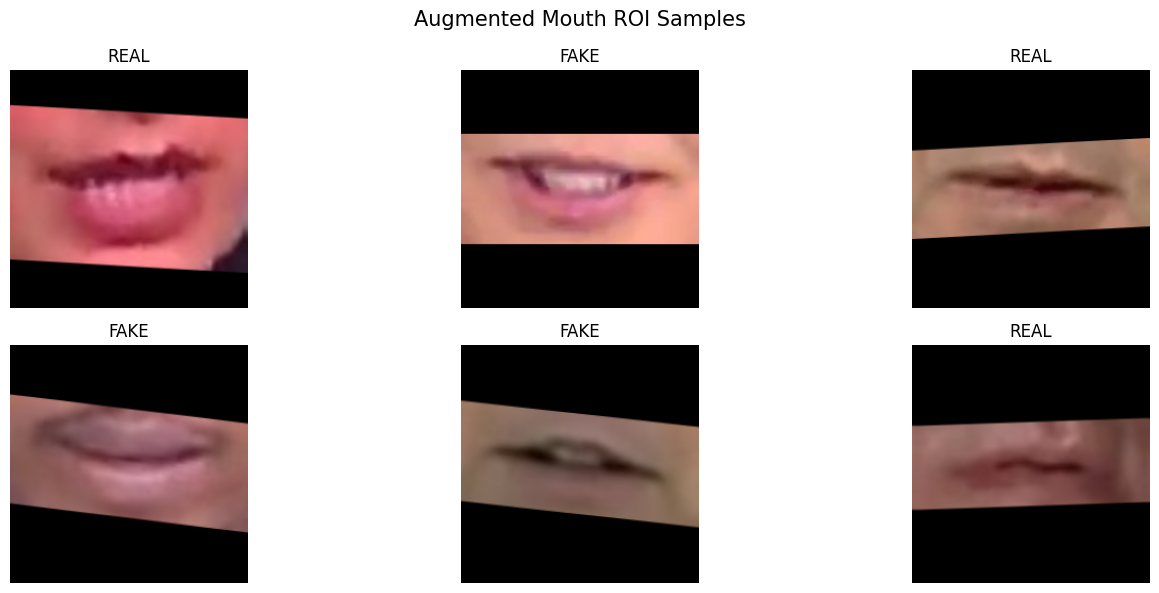


✓ augmentation_config.json kaydedildi.

✓ CELL 5 BAŞARIYLA TAMAMLANDI
✓ Train verisine hafif augmentation uygulandı.
✓ Validation verisine augmentation uygulanmadı.
✓ Test verisine augmentation uygulanmadı.
✓ Xception preprocess_input uygulandı.
✓ Train / Val / Test model girişine hazır.
✓ Henüz Xception modeli oluşturulmadı.
✓ Henüz model eğitimi başlamadı.


In [5]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 5 - Data Augmentation and Xception Preprocessing
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Yalnızca TRAIN verisine hafif data augmentation uygulamak.
# 2) Validation ve Test verisini olduğu gibi bırakmak.
# 3) Xception için gerekli preprocess_input işlemini uygulamak.
# 4) Train / Val / Test datasetlerini modele uygun hale getirmek.
#
# ----------------------------------------------------------
# NEDEN HAFİF AUGMENTATION?
#
# Deepfake tespitinde lokal doku ve ince artefaktlar önemlidir.
#
# Çok agresif:
# - rotation
# - zoom
# - blur
# - contrast distortion
#
# kullanmak gerçek deepfake izlerini bozabilir.
#
# Bu nedenle yalnızca sınırlı ve mantıklı dönüşümler kullanıyoruz.
# ==========================================================


print("=" * 70)
print("XCEPTION - DATA AUGMENTATION & PREPROCESSING")
print("=" * 70)


# ==========================================================
# 1. DATA AUGMENTATION KATMANLARI
# ==========================================================
#
# Ağız ROI için kontrollü augmentation:
#
# RandomFlip:
# Yatay çevirme.
#
# RandomRotation:
# Çok küçük açı.
#
# RandomZoom:
# Hafif yakınlaşma / uzaklaşma.
#
# RandomContrast:
# Küçük kontrast değişimi.
#
# NOT:
# Blur veya güçlü renk manipülasyonu kullanmıyoruz.


data_augmentation = keras.Sequential(
    [

        # --------------------------------------------------
        # YATAY ÇEVİRME
        # --------------------------------------------------
        #
        # İnsan yüzünün sağ-sol simetrisi nedeniyle
        # kontrollü horizontal flip makul bir augmentation'dır.

        layers.RandomFlip(
            mode="horizontal",
            seed=SEED
        ),


        # --------------------------------------------------
        # KÜÇÜK ROTATION
        # --------------------------------------------------
        #
        # factor=0.02 yaklaşık çok küçük açılar üretir.
        # Ağzın geometrisini aşırı bozmaz.

        layers.RandomRotation(
            factor=0.02,
            fill_mode="reflect",
            seed=SEED
        ),


        # --------------------------------------------------
        # HAFİF ZOOM
        # --------------------------------------------------
        #
        # %5 civarında hafif zoom.
        #
        # Deepfake artefaktlarının yapısını korurken
        # modele küçük ölçek değişimleri kazandırır.

        layers.RandomZoom(
            height_factor=(-0.05, 0.05),
            width_factor=(-0.05, 0.05),
            fill_mode="reflect",
            seed=SEED
        ),


        # --------------------------------------------------
        # HAFİF KONTRAST DEĞİŞİMİ
        # --------------------------------------------------
        #
        # Farklı kamera / video koşullarına karşı
        # küçük kontrast toleransı sağlar.

        layers.RandomContrast(
            factor=0.05,
            seed=SEED
        )
    ],
    name="mouth_data_augmentation"
)


# ==========================================================
# 2. AUGMENTATION + XCEPTION PREPROCESSING
# ==========================================================

def prepare_train_batch(images, labels):
    """
    Train batch'i Xception eğitimine hazırlar.

    İşlem sırası:
    1) Hafif augmentation
    2) Xception preprocess_input

    Xception preprocess_input:
    Piksel değerlerini modelin beklediği ölçeğe getirir.
    """

    # ------------------------------------------------------
    # TRAIN AUGMENTATION
    # ------------------------------------------------------

    images = data_augmentation(
        images,
        training=True
    )


    # ------------------------------------------------------
    # XCEPTION PREPROCESS
    # ------------------------------------------------------
    #
    # preprocess_input görüntü değerlerini
    # yaklaşık [-1, 1] aralığına dönüştürür.

    images = preprocess_input(
        images
    )


    return images, labels


# ==========================================================
# 3. VALIDATION / TEST PREPROCESSING
# ==========================================================

def prepare_eval_batch(images, labels):
    """
    Validation ve Test batch'lerini hazırlar.

    Augmentation YOKTUR.
    Yalnızca Xception preprocess_input uygulanır.
    """

    images = preprocess_input(
        images
    )

    return images, labels


# ==========================================================
# 4. TRAIN DATASETİ GÜNCELLE
# ==========================================================

train_ds_xception = train_ds.map(
    prepare_train_batch,
    num_parallel_calls=tf.data.AUTOTUNE
)


# ==========================================================
# 5. VALIDATION DATASETİ GÜNCELLE
# ==========================================================

val_ds_xception = val_ds.map(
    prepare_eval_batch,
    num_parallel_calls=tf.data.AUTOTUNE
)


# ==========================================================
# 6. TEST DATASETİ GÜNCELLE
# ==========================================================

test_ds_xception = test_ds.map(
    prepare_eval_batch,
    num_parallel_calls=tf.data.AUTOTUNE
)


# ==========================================================
# 7. PREFETCH
# ==========================================================

train_ds_xception = train_ds_xception.prefetch(
    tf.data.AUTOTUNE
)

val_ds_xception = val_ds_xception.prefetch(
    tf.data.AUTOTUNE
)

test_ds_xception = test_ds_xception.prefetch(
    tf.data.AUTOTUNE
)


# ==========================================================
# 8. BİR TRAIN BATCH KONTROLÜ
# ==========================================================

aug_images, aug_labels = next(
    iter(train_ds_xception)
)


print("\n" + "=" * 70)
print("AUGMENTED TRAIN BATCH KONTROLÜ")
print("=" * 70)


print(
    "Image batch shape :",
    aug_images.shape
)


print(
    "Label batch shape :",
    aug_labels.shape
)


print(
    "Image dtype       :",
    aug_images.dtype
)


# ==========================================================
# 9. PIXEL RANGE KONTROLÜ
# ==========================================================
#
# Xception preprocess_input sonrası yaklaşık:
#
# -1 ... +1
#
# aralığı beklenir.


print(
    "\nPixel minimum:",
    float(
        tf.reduce_min(
            aug_images
        ).numpy()
    )
)


print(
    "Pixel maximum:",
    float(
        tf.reduce_max(
            aug_images
        ).numpy()
    )
)


# ==========================================================
# 10. AUGMENTATION GÖRSEL KONTROLÜ
# ==========================================================
#
# Aynı batch'ten birkaç görüntüyü gösteriyoruz.
#
# preprocess_input sonrası görüntüler [-1,1] aralığında.
# Görselleştirme için tekrar yaklaşık [0,1] aralığına getiriyoruz.


display_count = min(
    6,
    int(
        aug_images.shape[0]
    )
)


plt.figure(
    figsize=(15, 6)
)


for i in range(
    display_count
):

    plt.subplot(
        2,
        3,
        i + 1
    )


    # Xception preprocessing'i görselleştirme amacıyla geri al:
    #
    # [-1,1] -> [0,1]

    display_image = (
        aug_images[i] + 1.0
    ) / 2.0


    display_image = tf.clip_by_value(
        display_image,
        0.0,
        1.0
    )


    plt.imshow(
        display_image.numpy()
    )


    label_value = int(
        aug_labels[i].numpy()
    )


    label_name = (
        "FAKE"
        if label_value == 1
        else "REAL"
    )


    plt.title(
        label_name
    )

    plt.axis(
        "off"
    )


plt.suptitle(
    "Augmented Mouth ROI Samples",
    fontsize=15
)

plt.tight_layout()

plt.show()


# ==========================================================
# 11. AUGMENTATION AYARLARINI KAYDET
# ==========================================================
#
# Deneyin tekrar üretilebilir olması için
# kullanılan augmentation ayarlarını JSON olarak kaydediyoruz.


augmentation_config = {

    "random_flip":
        "horizontal",

    "random_rotation_factor":
        0.02,

    "random_zoom_height":
        [
            -0.05,
            0.05
        ],

    "random_zoom_width":
        [
            -0.05,
            0.05
        ],

    "random_contrast_factor":
        0.05,

    "xception_preprocess_input":
        True,

    "train_augmentation":
        True,

    "validation_augmentation":
        False,

    "test_augmentation":
        False,

    "seed":
        int(
            SEED
        )
}


AUGMENTATION_CONFIG_PATH = (
    RESULTS_DIR
    / "augmentation_config.json"
)


with open(
    AUGMENTATION_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        augmentation_config,
        file,
        ensure_ascii=False,
        indent=4
    )


print(
    "\n✓ augmentation_config.json kaydedildi."
)


# ==========================================================
# 12. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)

print(
    "✓ CELL 5 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ Train verisine hafif augmentation uygulandı."
)

print(
    "✓ Validation verisine augmentation uygulanmadı."
)

print(
    "✓ Test verisine augmentation uygulanmadı."
)

print(
    "✓ Xception preprocess_input uygulandı."
)

print(
    "✓ Train / Val / Test model girişine hazır."
)

print(
    "✓ Henüz Xception modeli oluşturulmadı."
)

print(
    "✓ Henüz model eğitimi başlamadı."
)

print("=" * 70)

In [6]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 6 - Build Xception Model
# ==========================================================

# Bu hücrenin amacı:
#
# 1) ImageNet ağırlıklarıyla Xception backbone'u yüklemek.
# 2) Backbone'u ilk eğitim aşamasında dondurmak.
# 3) Üzerine yeni sınıflandırıcı katmanları eklemek.
# 4) Binary classification için sigmoid çıkış üretmek.
# 5) Modeli compile etmek.
#
# ÖNEMLİ:
# Bu hücre model mimarisini oluşturur.
# Henüz model.fit() çalıştırılmaz.
# ==========================================================


print("=" * 70)
print("XCEPTION MODEL BUILD")
print("=" * 70)


# ==========================================================
# 1. XCEPTION BACKBONE
# ==========================================================
#
# include_top=False:
# ImageNet'in orijinal 1000 sınıflı classifier kısmını
# kullanmıyoruz.
#
# weights="imagenet":
# Önceden öğrenilmiş ağırlıklardan başlıyoruz.
#
# input_shape:
# Mouth ROI görüntülerimiz 224x224 RGB.


xception_base = Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        3
    )
)


# ==========================================================
# 2. BACKBONE'U DONDUR
# ==========================================================
#
# İlk eğitim aşamasında Xception convolution katmanlarını
# değiştirmiyoruz.
#
# Yalnızca ekleyeceğimiz classifier katmanları eğitilecek.
#
# Bunun avantajı:
# - Küçük veri setinde overfitting riskini azaltır.
# - Önceden öğrenilmiş genel görsel feature'ları korur.
# - Eğitimi daha stabil başlatır.


xception_base.trainable = False


print(
    "\n✓ Xception backbone yüklendi."
)

print(
    "✓ ImageNet ağırlıkları kullanılıyor."
)

print(
    "✓ Backbone ilk aşama için donduruldu."
)


# ==========================================================
# 3. MODEL INPUT
# ==========================================================

inputs = keras.Input(
    shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        3
    ),
    name="mouth_roi_input"
)


# ==========================================================
# 4. XCEPTION FEATURE EXTRACTION
# ==========================================================
#
# trainable=False olduğu için backbone weights güncellenmez.
#
# training=False:
# BatchNorm katmanlarının inference modunda çalışmasını sağlar.
# Transfer learning'in ilk aşamasında daha güvenli bir seçimdir.


x = xception_base(
    inputs,
    training=False
)


# ==========================================================
# 5. GLOBAL AVERAGE POOLING
# ==========================================================
#
# Xception'ın son convolution feature map'lerini
# tek bir feature vector haline getirir.
#
# Örneğin:
#
# H x W x C
#
#          ↓
#
#        C boyutlu
#       feature vector


x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(
    x
)


# ==========================================================
# 6. DROPOUT
# ==========================================================
#
# Küçük veri setinde overfitting'i azaltmak için
# Dropout kullanıyoruz.
#
# 0.30 = eğitim sırasında feature'ların %30'u rastgele
# geçici olarak kapatılır.


x = layers.Dropout(
    rate=0.30,
    name="dropout"
)(
    x
)


# ==========================================================
# 7. ARA DENSE KATMAN
# ==========================================================
#
# Xception'dan gelen deep feature vector ile
# final sınıflandırıcı arasında küçük bir öğrenilebilir
# representation oluşturuyoruz.


x = layers.Dense(
    units=256,
    activation="relu",
    name="dense_256"
)(
    x
)


# ==========================================================
# 8. İKİNCİ DROPOUT
# ==========================================================

x = layers.Dropout(
    rate=0.20,
    name="dropout_2"
)(
    x
)


# ==========================================================
# 9. FINAL OUTPUT
# ==========================================================
#
# Binary classification:
#
# REAL = 0
# FAKE = 1
#
# Sigmoid çıkış:
#
# 0'a yakın -> REAL
# 1'e yakın -> FAKE


outputs = layers.Dense(
    units=1,
    activation="sigmoid",
    name="fake_probability"
)(
    x
)


# ==========================================================
# 10. MODEL OLUŞTUR
# ==========================================================

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Mouth_Xception_Deepfake_Detector"
)


# ==========================================================
# 11. OPTIMIZER
# ==========================================================
#
# İlk transfer-learning aşamasında:
#
# Adam optimizer
# learning_rate = 1e-4
#
# oldukça güvenli bir başlangıçtır.


INITIAL_LEARNING_RATE = 1e-4


optimizer = keras.optimizers.Adam(
    learning_rate=INITIAL_LEARNING_RATE
)


# ==========================================================
# 12. LOSS FUNCTION
# ==========================================================
#
# İki sınıflı problem:
#
# REAL / FAKE
#
# Dolayısıyla Binary Cross Entropy kullanıyoruz.


loss_function = keras.losses.BinaryCrossentropy()


# ==========================================================
# 13. TRAINING METRICS
# ==========================================================
#
# Eğitim sırasında:
#
# accuracy
# precision
# recall
# AUC
#
# takip edilecek.
#
# F1 score'u daha sonra test tahminlerinden sklearn ile
# ayrıca hesaplayacağız.


training_metrics = [

    keras.metrics.BinaryAccuracy(
        name="accuracy"
    ),

    keras.metrics.Precision(
        name="precision"
    ),

    keras.metrics.Recall(
        name="recall"
    ),

    keras.metrics.AUC(
        name="auc"
    )
]


# ==========================================================
# 14. MODEL COMPILE
# ==========================================================

model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=training_metrics
)


# ==========================================================
# 15. MODEL SUMMARY
# ==========================================================

print(
    "\n"
    + "=" * 70
)

print(
    "MODEL SUMMARY"
)

print(
    "=" * 70
)


model.summary()


# ==========================================================
# 16. PARAMETRE SAYILARI
# ==========================================================

total_params = model.count_params()


trainable_params = sum(
    int(
        np.prod(
            variable.shape
        )
    )
    for variable in model.trainable_weights
)


non_trainable_params = (
    total_params
    - trainable_params
)


print(
    "\n"
    + "=" * 70
)

print(
    "PARAMETER SUMMARY"
)

print(
    "=" * 70
)


print(
    f"Total parameters      : "
    f"{total_params:,}"
)


print(
    f"Trainable parameters  : "
    f"{trainable_params:,}"
)


print(
    f"Frozen parameters     : "
    f"{non_trainable_params:,}"
)


# ==========================================================
# 17. BACKBONE DURUMU
# ==========================================================

print(
    "\nXception backbone trainable:",
    xception_base.trainable
)


# ==========================================================
# 18. MODEL CONFIG KAYDI
# ==========================================================
#
# Deney tekrarlanabilirliği için kullanılan model ayarlarını
# JSON olarak kaydediyoruz.


model_config = {

    "model_name":
        "Xception",

    "experiment_name":
        "Mouth_Xception_Deepfake_Detector",

    "weights":
        "imagenet",

    "include_top":
        False,

    "input_size": [
        int(
            IMG_HEIGHT
        ),
        int(
            IMG_WIDTH
        ),
        3
    ],

    "backbone_trainable_initially":
        False,

    "global_average_pooling":
        True,

    "dropout_1":
        0.30,

    "dense_units":
        256,

    "dense_activation":
        "relu",

    "dropout_2":
        0.20,

    "output_units":
        1,

    "output_activation":
        "sigmoid",

    "optimizer":
        "Adam",

    "initial_learning_rate":
        float(
            INITIAL_LEARNING_RATE
        ),

    "loss":
        "BinaryCrossentropy",

    "class_mapping": {
        "real": 0,
        "fake": 1
    },

    "metrics": [
        "accuracy",
        "precision",
        "recall",
        "auc"
    ]
}


MODEL_CONFIG_PATH = (
    RESULTS_DIR
    / "xception_model_config.json"
)


with open(
    MODEL_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_config,
        file,
        ensure_ascii=False,
        indent=4
    )


print(
    "\n✓ xception_model_config.json kaydedildi."
)


# ==========================================================
# 19. CELL SONUCU
# ==========================================================

print(
    "\n"
    + "=" * 70
)

print(
    "✓ CELL 6 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ ImageNet pretrained Xception hazır."
)

print(
    "✓ Xception backbone donduruldu."
)

print(
    "✓ Deep feature extraction katmanları hazır."
)

print(
    "✓ Global Average Pooling eklendi."
)

print(
    "✓ Dense classifier eklendi."
)

print(
    "✓ REAL = 0 / FAKE = 1."
)

print(
    "✓ Model compile edildi."
)

print(
    "✓ Henüz eğitim başlamadı."
)

print("=" * 70)

XCEPTION MODEL BUILD
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

✓ Xception backbone yüklendi.
✓ ImageNet ağırlıkları kullanılıyor.
✓ Backbone ilk aşama için donduruldu.

MODEL SUMMARY


Model: "Mouth_Xception_Deepfake_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mouth_roi_input (InputLayer)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fake_probability (Dense)        │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,386,281 (81.58 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)


PARAMETER SUMMARY
Total parameters      : 21,386,281
Trainable parameters  : 524,801
Frozen parameters     : 20,861,480

Xception backbone trainable: False

✓ xception_model_config.json kaydedildi.

✓ CELL 6 BAŞARIYLA TAMAMLANDI
✓ ImageNet pretrained Xception hazır.
✓ Xception backbone donduruldu.
✓ Deep feature extraction katmanları hazır.
✓ Global Average Pooling eklendi.
✓ Dense classifier eklendi.
✓ REAL = 0 / FAKE = 1.
✓ Model compile edildi.
✓ Henüz eğitim başlamadı.


In [7]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 7 - Initial Training with Frozen Xception Backbone
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Xception backbone dondurulmuş halde ilk eğitimi başlatmak.
# 2) Yalnızca üstteki classifier katmanlarını eğitmek.
# 3) Validation performansını takip etmek.
# 4) En iyi modeli otomatik kaydetmek.
# 5) Overfitting / gereksiz uzun eğitim riskini azaltmak.
#
# Bu aşama bittikten sonra fine-tuning'e geçeceğiz.
# ==========================================================


print("=" * 70)
print("XCEPTION - INITIAL FROZEN BACKBONE TRAINING")
print("=" * 70)


# ==========================================================
# 1. EPOCH SAYISI
# ==========================================================
#
# İlk aşamada 15 epoch yeterli bir başlangıçtır.
#
# EarlyStopping nedeniyle model gerekirse daha erken duracaktır.

INITIAL_EPOCHS = 15


# ==========================================================
# 2. MODEL CHECKPOINT YOLU
# ==========================================================
#
# Validation AUC değeri en iyi olduğunda model kaydedilecek.
#
# .keras formatı yeni Keras formatıdır.


BEST_FROZEN_MODEL_PATH = (
    MODEL_DIR
    / "best_xception_frozen.keras"
)


# ==========================================================
# 3. TRAINING LOG CSV
# ==========================================================
#
# Her epoch sonucunu ayrıca CSV olarak saklıyoruz.
#
# Böylece daha sonra raporda:
#
# - loss
# - accuracy
# - precision
# - recall
# - auc
#
# değerlerini inceleyebiliriz.


FROZEN_TRAINING_LOG_PATH = (
    RESULTS_DIR
    / "frozen_training_log.csv"
)


# ==========================================================
# 4. CALLBACK - MODEL CHECKPOINT
# ==========================================================
#
# En yüksek validation AUC değerine sahip modeli kaydeder.
#
# Neden val_auc?
#
# Accuracy tek başına yeterli değildir.
# Deepfake detection binary classification probleminde
# AUC modelin sınıfları ayırma gücü açısından önemli bir metriktir.


checkpoint_callback = keras.callbacks.ModelCheckpoint(

    filepath=str(
        BEST_FROZEN_MODEL_PATH
    ),

    monitor="val_auc",

    mode="max",

    save_best_only=True,

    save_weights_only=False,

    verbose=1
)


# ==========================================================
# 5. CALLBACK - EARLY STOPPING
# ==========================================================
#
# Validation AUC 4 epoch boyunca iyileşmezse eğitim durur.
#
# restore_best_weights=True:
# eğitim sonunda en iyi epoch ağırlıklarına geri döner.


early_stopping_callback = keras.callbacks.EarlyStopping(

    monitor="val_auc",

    mode="max",

    patience=4,

    restore_best_weights=True,

    verbose=1
)


# ==========================================================
# 6. CALLBACK - REDUCE LEARNING RATE
# ==========================================================
#
# Validation loss 2 epoch boyunca iyileşmezse
# learning rate yarıya düşürülür.


reduce_lr_callback = keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    mode="min",

    factor=0.5,

    patience=2,

    min_lr=1e-7,

    verbose=1
)


# ==========================================================
# 7. CALLBACK - CSV LOGGER
# ==========================================================

csv_logger_callback = keras.callbacks.CSVLogger(

    filename=str(
        FROZEN_TRAINING_LOG_PATH
    ),

    separator=",",

    append=False
)


# ==========================================================
# 8. CALLBACK LİSTESİ
# ==========================================================

callbacks_initial = [

    checkpoint_callback,

    early_stopping_callback,

    reduce_lr_callback,

    csv_logger_callback
]


# ==========================================================
# 9. TRAINING ÖNCESİ MODEL DURUMU
# ==========================================================

print("\nTraining configuration:")

print(
    f"Initial epochs        : "
    f"{INITIAL_EPOCHS}"
)

print(
    f"Initial learning rate : "
    f"{INITIAL_LEARNING_RATE}"
)

print(
    f"Batch size            : "
    f"{BATCH_SIZE}"
)

print(
    f"Train samples         : "
    f"{TRAIN_TOTAL}"
)

print(
    f"Validation samples    : "
    f"{VAL_TOTAL}"
)

print(
    f"Xception trainable    : "
    f"{xception_base.trainable}"
)

print(
    f"Best model path       : "
    f"{BEST_FROZEN_MODEL_PATH}"
)


# ==========================================================
# 10. EĞİTİM BAŞLANGIÇ ZAMANI
# ==========================================================

initial_training_start = time.perf_counter()


# ==========================================================
# 11. MODEL TRAINING
# ==========================================================
#
# İlk gerçek model.fit() burada çalışıyor.
#
# train_ds_xception:
# augmentation + Xception preprocessing uygulanmış train set.
#
# val_ds_xception:
# augmentation yok, yalnızca preprocessing var.


history_frozen = model.fit(

    train_ds_xception,

    validation_data=val_ds_xception,

    epochs=INITIAL_EPOCHS,

    callbacks=callbacks_initial,

    verbose=1
)


# ==========================================================
# 12. EĞİTİM SÜRESİ
# ==========================================================

initial_training_seconds = (
    time.perf_counter()
    - initial_training_start
)


initial_training_minutes = (
    initial_training_seconds
    / 60
)


print("\n" + "=" * 70)

print(
    f"Frozen training süresi: "
    f"{initial_training_minutes:.2f} dakika"
)

print("=" * 70)


# ==========================================================
# 13. GERÇEKLEŞEN EPOCH SAYISI
# ==========================================================

completed_initial_epochs = len(
    history_frozen.history[
        "loss"
    ]
)


print(
    f"\nGerçekleşen epoch sayısı: "
    f"{completed_initial_epochs}"
)


# ==========================================================
# 14. EN İYİ VALIDATION AUC
# ==========================================================

best_val_auc = max(
    history_frozen.history[
        "val_auc"
    ]
)


best_val_auc_epoch = (
    int(
        np.argmax(
            history_frozen.history[
                "val_auc"
            ]
        )
    )
    + 1
)


print(
    f"En iyi validation AUC: "
    f"{best_val_auc:.4f}"
)

print(
    f"En iyi epoch         : "
    f"{best_val_auc_epoch}"
)


# ==========================================================
# 15. EN İYİ VALIDATION ACCURACY
# ==========================================================

best_val_accuracy = max(
    history_frozen.history[
        "val_accuracy"
    ]
)


print(
    f"En iyi validation accuracy: "
    f"{best_val_accuracy:.4f}"
)


# ==========================================================
# 16. TRAINING HISTORY'Yİ DATAFRAME'E ÇEVİR
# ==========================================================

history_frozen_df = pd.DataFrame(
    history_frozen.history
)


history_frozen_df.insert(
    0,
    "epoch",
    range(
        1,
        len(history_frozen_df) + 1
    )
)


# ==========================================================
# 17. HISTORY CSV KAYDET
# ==========================================================

FROZEN_HISTORY_PATH = (
    RESULTS_DIR
    / "frozen_training_history.csv"
)


history_frozen_df.to_csv(

    FROZEN_HISTORY_PATH,

    index=False,

    encoding="utf-8-sig"
)


print(
    "\n✓ frozen_training_history.csv kaydedildi."
)


# ==========================================================
# 18. EĞİTİM ÖZET JSON
# ==========================================================

frozen_training_summary = {

    "training_stage":
        "frozen_backbone",

    "requested_epochs":
        int(
            INITIAL_EPOCHS
        ),

    "completed_epochs":
        int(
            completed_initial_epochs
        ),

    "batch_size":
        int(
            BATCH_SIZE
        ),

    "initial_learning_rate":
        float(
            INITIAL_LEARNING_RATE
        ),

    "train_samples":
        int(
            TRAIN_TOTAL
        ),

    "validation_samples":
        int(
            VAL_TOTAL
        ),

    "best_validation_auc":
        float(
            best_val_auc
        ),

    "best_validation_auc_epoch":
        int(
            best_val_auc_epoch
        ),

    "best_validation_accuracy":
        float(
            best_val_accuracy
        ),

    "training_seconds":
        float(
            initial_training_seconds
        ),

    "training_minutes":
        float(
            initial_training_minutes
        ),

    "best_model_path":
        str(
            BEST_FROZEN_MODEL_PATH
        )
}


FROZEN_SUMMARY_PATH = (
    RESULTS_DIR
    / "frozen_training_summary.json"
)


with open(
    FROZEN_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(

        frozen_training_summary,

        file,

        ensure_ascii=False,

        indent=4
    )


print(
    "✓ frozen_training_summary.json kaydedildi."
)


# ==========================================================
# 19. MODEL DOSYASI KONTROLÜ
# ==========================================================

print(
    "\nBest model mevcut mu? :",
    BEST_FROZEN_MODEL_PATH.exists()
)


# ==========================================================
# 20. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)

print(
    "✓ CELL 7 TAMAMLANDI"
)

print(
    "✓ Frozen Xception eğitimi tamamlandı."
)

print(
    "✓ En iyi validation AUC modeli kaydedildi."
)

print(
    "✓ Training log kaydedildi."
)

print(
    "✓ EarlyStopping aktifti."
)

print(
    "✓ ReduceLROnPlateau aktifti."
)

print(
    "✓ Sonraki aşama: Fine-Tuning."
)

print("=" * 70)

XCEPTION - INITIAL FROZEN BACKBONE TRAINING

Training configuration:
Initial epochs        : 15
Initial learning rate : 0.0001
Batch size            : 16
Train samples         : 2389
Validation samples    : 296
Xception trainable    : False
Best model path       : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/xception_experiment/models/best_xception_frozen.keras
Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5607 - auc: 0.5848 - loss: 0.6819 - precision: 0.5728 - recall: 0.5363
Epoch 1: val_auc improved from None to 0.69623, saving model to /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/xception_experiment/models/best_xception_frozen.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/xception_experiment/models/best_xception_frozen.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 641s 4s/step - accuracy: 0.5852 - auc: 0.6208 - loss: 0.6687 - precision: 0.5893 - recall: 0.556

In [8]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 8 - Xception Fine-Tuning
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Cell 7'de eğitilen en iyi frozen modeli yüklemek.
# 2) Xception backbone'un tamamını artık erişilebilir yapmak.
# 3) Ancak yalnızca SON belirli sayıdaki katmanı eğitime açmak.
# 4) BatchNormalization katmanlarını frozen bırakmak.
# 5) Learning rate'i ciddi şekilde azaltmak.
# 6) Fine-tuning ile ağız bölgesine daha özel deep feature'lar
#    öğrenilmesini sağlamak.
#
# ----------------------------------------------------------
# NEDEN FINE-TUNING?
#
# İlk aşamada Xception:
#
# ImageNet'ten öğrendiği genel görsel özellikleri kullandı.
#
# Fine-tuning aşamasında ise son convolution katmanlarının
# ağız deepfake problemine daha fazla adapte olması amaçlanır.
#
# Örneğin model;
#
# - dudak-cilt geçişleri
# - lokal texture farklılıkları
# - diş / ağız içi yapı
# - blending artefaktları
# - doğal olmayan kenar yapıları
#
# gibi ayırt edici örüntülere daha duyarlı hale gelebilir.
#
# NOT:
# Bu özelliklerin gerçekten öğrenildiğini yalnızca model
# performansından kesin söyleyemeyiz. Daha sonra Grad-CAM gibi
# açıklanabilirlik yöntemleriyle inceleyebiliriz.
# ==========================================================


print("=" * 70)
print("XCEPTION - FINE-TUNING")
print("=" * 70)


# ==========================================================
# 1. CELL 7 MODELİNİ KONTROL ET
# ==========================================================

if not BEST_FROZEN_MODEL_PATH.exists():

    raise FileNotFoundError(
        "Cell 7'de kaydedilmesi gereken "
        "best_xception_frozen.keras bulunamadı."
    )


print(
    "\n✓ Frozen aşamadaki en iyi model bulundu."
)


# ==========================================================
# 2. EN İYİ FROZEN MODELİ YÜKLE
# ==========================================================
#
# Cell 7'nin son epoch'unu değil,
# validation AUC açısından EN İYİ modeli kullanıyoruz.


model = keras.models.load_model(
    BEST_FROZEN_MODEL_PATH
)


print(
    "✓ En iyi frozen model yüklendi."
)


# ==========================================================
# 3. MODEL İÇERİSİNDEKİ XCEPTION BACKBONE'U BUL
# ==========================================================

xception_base = model.get_layer(
    "xception"
)


print(
    "\nXception katman sayısı:",
    len(xception_base.layers)
)


# ==========================================================
# 4. BACKBONE'U TRAINABLE YAP
# ==========================================================
#
# Önce genel olarak trainable=True diyoruz.
#
# Bir sonraki adımda katmanların büyük bölümünü tekrar
# donduracağız.


xception_base.trainable = True


# ==========================================================
# 5. KAÇ SON KATMANI AÇACAĞIZ?
# ==========================================================
#
# İlk fine-tuning denemesinde son 30 katmanı açıyoruz.
#
# Bu değer kontrollü bir başlangıçtır.
#
# Çok fazla katmanı bir anda açmak:
# - overfitting
# - pretrained özelliklerin bozulması
# - training instability
#
# oluşturabilir.


UNFREEZE_LAST_N = 30


# ==========================================================
# 6. ÖNCE TÜM BACKBONE KATMANLARINI DONDUR
# ==========================================================

for layer in xception_base.layers:

    layer.trainable = False


# ==========================================================
# 7. SON N KATMANI AÇ
# ==========================================================

for layer in xception_base.layers[
    -UNFREEZE_LAST_N:
]:

    # ------------------------------------------------------
    # BatchNormalization özel durumu
    # ------------------------------------------------------
    #
    # Küçük dataset + küçük batch size durumunda
    # BatchNorm istatistiklerini yeniden öğrenmek
    # kararsızlık oluşturabilir.
    #
    # Bu nedenle BatchNormalization katmanlarını
    # frozen bırakıyoruz.

    if isinstance(
        layer,
        layers.BatchNormalization
    ):

        layer.trainable = False

    else:

        layer.trainable = True


# ==========================================================
# 8. TRAINABLE BACKBONE KATMANLARINI SAY
# ==========================================================

trainable_backbone_layers = [

    layer.name

    for layer in xception_base.layers

    if layer.trainable
]


print(
    f"\nFine-tuning için açılan backbone katman sayısı: "
    f"{len(trainable_backbone_layers)}"
)


print(
    "\nTrainable Xception katmanlarından son birkaç örnek:"
)


for layer_name in trainable_backbone_layers[
    -10:
]:

    print(
        " -",
        layer_name
    )


# ==========================================================
# 9. FINE-TUNING LEARNING RATE
# ==========================================================
#
# Fine-tuning sırasında pretrained ağırlıkları
# hızlı biçimde bozmak istemiyoruz.
#
# Bu nedenle ilk aşamadaki 1e-4 yerine:
#
# 1e-5
#
# kullanıyoruz.


FINE_TUNE_LEARNING_RATE = 1e-5


fine_tune_optimizer = keras.optimizers.Adam(
    learning_rate=FINE_TUNE_LEARNING_RATE
)


# ==========================================================
# 10. MODELİ YENİDEN COMPILE ET
# ==========================================================
#
# trainable katmanlar değiştirildikten sonra modelin
# MUTLAKA yeniden compile edilmesi gerekir.


model.compile(

    optimizer=fine_tune_optimizer,

    loss=keras.losses.BinaryCrossentropy(),

    metrics=[

        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        ),

        keras.metrics.AUC(
            name="auc"
        )
    ]
)


print(
    "\n✓ Model fine-tuning için yeniden compile edildi."
)


# ==========================================================
# 11. PARAMETRE SAYILARI
# ==========================================================

total_params_ft = model.count_params()


trainable_params_ft = sum(

    int(
        np.prod(
            variable.shape
        )
    )

    for variable in model.trainable_weights
)


frozen_params_ft = (
    total_params_ft
    - trainable_params_ft
)


print("\n" + "=" * 70)
print("FINE-TUNING PARAMETER SUMMARY")
print("=" * 70)


print(
    f"Total parameters     : "
    f"{total_params_ft:,}"
)


print(
    f"Trainable parameters : "
    f"{trainable_params_ft:,}"
)


print(
    f"Frozen parameters    : "
    f"{frozen_params_ft:,}"
)


# ==========================================================
# 12. FINE-TUNING EPOCH SAYISI
# ==========================================================

FINE_TUNE_EPOCHS = 10


# ==========================================================
# 13. EN İYİ FINE-TUNED MODEL YOLU
# ==========================================================

BEST_FINE_TUNED_MODEL_PATH = (
    MODEL_DIR
    / "best_xception_finetuned.keras"
)


# ==========================================================
# 14. FINE-TUNING CSV LOG
# ==========================================================

FINE_TUNE_LOG_PATH = (
    RESULTS_DIR
    / "finetune_training_log.csv"
)


# ==========================================================
# 15. MODEL CHECKPOINT
# ==========================================================

finetune_checkpoint = (
    keras.callbacks.ModelCheckpoint(

        filepath=str(
            BEST_FINE_TUNED_MODEL_PATH
        ),

        monitor="val_auc",

        mode="max",

        save_best_only=True,

        save_weights_only=False,

        verbose=1
    )
)


# ==========================================================
# 16. EARLY STOPPING
# ==========================================================

finetune_early_stopping = (
    keras.callbacks.EarlyStopping(

        monitor="val_auc",

        mode="max",

        patience=4,

        restore_best_weights=True,

        verbose=1
    )
)


# ==========================================================
# 17. REDUCE LEARNING RATE
# ==========================================================

finetune_reduce_lr = (
    keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=2,

        min_lr=1e-7,

        verbose=1
    )
)


# ==========================================================
# 18. CSV LOGGER
# ==========================================================

finetune_csv_logger = (
    keras.callbacks.CSVLogger(

        filename=str(
            FINE_TUNE_LOG_PATH
        ),

        separator=",",

        append=False
    )
)


# ==========================================================
# 19. CALLBACK LİSTESİ
# ==========================================================

callbacks_finetune = [

    finetune_checkpoint,

    finetune_early_stopping,

    finetune_reduce_lr,

    finetune_csv_logger
]


# ==========================================================
# 20. FINE-TUNING KONFİGÜRASYONU
# ==========================================================

print("\n" + "=" * 70)
print("FINE-TUNING CONFIGURATION")
print("=" * 70)


print(
    f"Unfreeze last N      : "
    f"{UNFREEZE_LAST_N}"
)


print(
    f"Trainable Xception   : "
    f"{len(trainable_backbone_layers)} katman"
)


print(
    f"Learning rate        : "
    f"{FINE_TUNE_LEARNING_RATE}"
)


print(
    f"Maximum epochs       : "
    f"{FINE_TUNE_EPOCHS}"
)


print(
    f"Train samples        : "
    f"{TRAIN_TOTAL}"
)


print(
    f"Validation samples   : "
    f"{VAL_TOTAL}"
)


# ==========================================================
# 21. FINE-TUNING BAŞLANGIÇ ZAMANI
# ==========================================================

finetune_start_time = (
    time.perf_counter()
)


# ==========================================================
# 22. FINE-TUNING BAŞLAT
# ==========================================================

history_finetune = model.fit(

    train_ds_xception,

    validation_data=(
        val_ds_xception
    ),

    epochs=(
        FINE_TUNE_EPOCHS
    ),

    callbacks=(
        callbacks_finetune
    ),

    verbose=1
)


# ==========================================================
# 23. FINE-TUNING SÜRESİ
# ==========================================================

finetune_seconds = (

    time.perf_counter()
    - finetune_start_time
)


finetune_minutes = (
    finetune_seconds
    / 60
)


print("\n" + "=" * 70)

print(
    f"Fine-tuning süresi: "
    f"{finetune_minutes:.2f} dakika"
)

print("=" * 70)


# ==========================================================
# 24. GERÇEKLEŞEN EPOCH SAYISI
# ==========================================================

completed_finetune_epochs = len(

    history_finetune.history[
        "loss"
    ]
)


# ==========================================================
# 25. EN İYİ VALIDATION AUC
# ==========================================================

best_finetune_val_auc = max(

    history_finetune.history[
        "val_auc"
    ]
)


best_finetune_epoch = (

    int(
        np.argmax(
            history_finetune.history[
                "val_auc"
            ]
        )
    )

    + 1
)


# ==========================================================
# 26. EN İYİ VALIDATION ACCURACY
# ==========================================================

best_finetune_val_accuracy = max(

    history_finetune.history[
        "val_accuracy"
    ]
)


print(
    f"\nGerçekleşen fine-tuning epoch: "
    f"{completed_finetune_epochs}"
)


print(
    f"En iyi fine-tuning val AUC    : "
    f"{best_finetune_val_auc:.4f}"
)


print(
    f"En iyi fine-tuning epoch      : "
    f"{best_finetune_epoch}"
)


print(
    f"En iyi fine-tuning val acc    : "
    f"{best_finetune_val_accuracy:.4f}"
)


# ==========================================================
# 27. HISTORY DATAFRAME
# ==========================================================

history_finetune_df = pd.DataFrame(
    history_finetune.history
)


history_finetune_df.insert(

    0,

    "epoch",

    range(
        1,
        len(history_finetune_df) + 1
    )
)


# ==========================================================
# 28. HISTORY CSV
# ==========================================================

FINE_TUNE_HISTORY_PATH = (
    RESULTS_DIR
    / "finetune_training_history.csv"
)


history_finetune_df.to_csv(

    FINE_TUNE_HISTORY_PATH,

    index=False,

    encoding="utf-8-sig"
)


print(
    "\n✓ finetune_training_history.csv kaydedildi."
)


# ==========================================================
# 29. FINE-TUNING SUMMARY JSON
# ==========================================================

finetune_summary = {

    "training_stage":
        "fine_tuning",

    "unfreeze_last_n":
        int(
            UNFREEZE_LAST_N
        ),

    "trainable_xception_layers":
        int(
            len(
                trainable_backbone_layers
            )
        ),

    "requested_epochs":
        int(
            FINE_TUNE_EPOCHS
        ),

    "completed_epochs":
        int(
            completed_finetune_epochs
        ),

    "learning_rate":
        float(
            FINE_TUNE_LEARNING_RATE
        ),

    "best_validation_auc":
        float(
            best_finetune_val_auc
        ),

    "best_validation_auc_epoch":
        int(
            best_finetune_epoch
        ),

    "best_validation_accuracy":
        float(
            best_finetune_val_accuracy
        ),

    "training_seconds":
        float(
            finetune_seconds
        ),

    "training_minutes":
        float(
            finetune_minutes
        ),

    "best_model_path":
        str(
            BEST_FINE_TUNED_MODEL_PATH
        )
}


FINE_TUNE_SUMMARY_PATH = (
    RESULTS_DIR
    / "finetune_training_summary.json"
)


with open(
    FINE_TUNE_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(

        finetune_summary,

        file,

        ensure_ascii=False,

        indent=4
    )


print(
    "✓ finetune_training_summary.json kaydedildi."
)


# ==========================================================
# 30. MODEL DOSYASI KONTROLÜ
# ==========================================================

print(
    "\nFine-tuned model mevcut mu? :",
    BEST_FINE_TUNED_MODEL_PATH.exists()
)


# ==========================================================
# 31. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)

print(
    "✓ CELL 8 TAMAMLANDI"
)

print(
    "✓ Xception fine-tuning tamamlandı."
)

print(
    "✓ Son katmanların bir kısmı ağız verisine adapte edildi."
)

print(
    "✓ BatchNormalization katmanları frozen tutuldu."
)

print(
    "✓ Düşük learning rate kullanıldı."
)

print(
    "✓ En iyi fine-tuned model kaydedildi."
)

print(
    "✓ Sonraki aşama: TEST SETİ DEĞERLENDİRMESİ."
)

print("=" * 70)

XCEPTION - FINE-TUNING

✓ Frozen aşamadaki en iyi model bulundu.
✓ En iyi frozen model yüklendi.

Xception katman sayısı: 132

Fine-tuning için açılan backbone katman sayısı: 21

Trainable Xception katmanlarından son birkaç örnek:
 - block13_sepconv1
 - block13_sepconv2_act
 - block13_sepconv2
 - conv2d_3
 - block13_pool
 - add_11
 - block14_sepconv1
 - block14_sepconv1_act
 - block14_sepconv2
 - block14_sepconv2_act

✓ Model fine-tuning için yeniden compile edildi.

FINE-TUNING PARAMETER SUMMARY
Total parameters     : 21,386,281
Trainable parameters : 9,446,609
Frozen parameters    : 11,939,672

FINE-TUNING CONFIGURATION
Unfreeze last N      : 30
Trainable Xception   : 21 katman
Learning rate        : 1e-05
Maximum epochs       : 10
Train samples        : 2389
Validation samples   : 296
Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6637 - auc: 0.7296 - loss: 0.6030 - precision: 0.6806 - recall: 0.6299
Epoch 1: val_auc improved from None to 0.73413, saving model to /

In [9]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 9 - Best Model Selection and Test Set Prediction
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Cell 7'deki Frozen Xception sonucunu okumak.
# 2) Cell 8'deki Fine-Tuned Xception sonucunu okumak.
# 3) Validation AUC değerlerine göre EN İYİ modeli seçmek.
# 4) Seçilen modeli yüklemek.
# 5) Daha önce model seçiminde kullanılmamış TEST SETİ
#    üzerinde tahmin üretmek.
# 6) Her test görüntüsü için P(fake) skorunu kaydetmek.
#
# ----------------------------------------------------------
# ÖNEMLİ BİLİMSEL NOKTA
# ----------------------------------------------------------
#
# Test setine bakarak model seçmiyoruz.
#
# Model seçimi:
#       VALIDATION AUC
#
# üzerinden yapılır.
#
# Test seti yalnızca seçilen nihai modelin
# tarafsız performansını ölçmek için kullanılır.
#
# REAL = 0
# FAKE = 1
#
# Sigmoid çıktısı:
#       P(fake)
#
# olarak yorumlanacaktır.
# ==========================================================


print("=" * 75)
print("XCEPTION - BEST MODEL SELECTION & TEST PREDICTION")
print("=" * 75)


# ==========================================================
# 1. CELL 7 VE CELL 8 ÖZET DOSYALARI
# ==========================================================

FROZEN_SUMMARY_PATH = (
    RESULTS_DIR
    / "frozen_training_summary.json"
)


FINE_TUNE_SUMMARY_PATH = (
    RESULTS_DIR
    / "finetune_training_summary.json"
)


# ==========================================================
# 2. DOSYALARIN VARLIĞINI KONTROL ET
# ==========================================================

if not FROZEN_SUMMARY_PATH.exists():

    raise FileNotFoundError(
        "Frozen training summary bulunamadı. "
        "Cell 7'nin başarıyla tamamlandığını kontrol et."
    )


if not FINE_TUNE_SUMMARY_PATH.exists():

    raise FileNotFoundError(
        "Fine-tuning summary bulunamadı. "
        "Cell 8'in başarıyla tamamlandığını kontrol et."
    )


print("\n✓ Cell 7 ve Cell 8 sonuç dosyaları bulundu.")


# ==========================================================
# 3. FROZEN SONUCU OKU
# ==========================================================

with open(
    FROZEN_SUMMARY_PATH,
    "r",
    encoding="utf-8"
) as file:

    frozen_summary = json.load(
        file
    )


# ==========================================================
# 4. FINE-TUNING SONUCU OKU
# ==========================================================

with open(
    FINE_TUNE_SUMMARY_PATH,
    "r",
    encoding="utf-8"
) as file:

    finetune_summary = json.load(
        file
    )


# ==========================================================
# 5. VALIDATION AUC DEĞERLERİNİ AL
# ==========================================================

frozen_val_auc = float(
    frozen_summary[
        "best_validation_auc"
    ]
)


finetune_val_auc = float(
    finetune_summary[
        "best_validation_auc"
    ]
)


print("\n" + "=" * 75)
print("VALIDATION MODEL COMPARISON")
print("=" * 75)


print(
    f"Frozen Xception best val AUC : "
    f"{frozen_val_auc:.4f}"
)


print(
    f"Fine-Tuned best val AUC      : "
    f"{finetune_val_auc:.4f}"
)


# ==========================================================
# 6. EN İYİ MODELİ SEÇ
# ==========================================================
#
# Test setine bakmıyoruz.
#
# Yalnızca VALIDATION AUC üzerinden seçim yapıyoruz.


if finetune_val_auc > frozen_val_auc:

    SELECTED_MODEL_STAGE = (
        "fine_tuned"
    )

    SELECTED_MODEL_PATH = (
        BEST_FINE_TUNED_MODEL_PATH
    )

    SELECTED_VAL_AUC = (
        finetune_val_auc
    )


else:

    SELECTED_MODEL_STAGE = (
        "frozen"
    )

    SELECTED_MODEL_PATH = (
        BEST_FROZEN_MODEL_PATH
    )

    SELECTED_VAL_AUC = (
        frozen_val_auc
    )


print("\n" + "=" * 75)
print("SELECTED FINAL MODEL")
print("=" * 75)


print(
    "Selected stage :",
    SELECTED_MODEL_STAGE
)


print(
    "Selected val AUC:",
    f"{SELECTED_VAL_AUC:.4f}"
)


print(
    "Model path:"
)

print(
    SELECTED_MODEL_PATH
)


# ==========================================================
# 7. MODEL DOSYASI GERÇEKTEN VAR MI?
# ==========================================================

if not Path(
    SELECTED_MODEL_PATH
).exists():

    raise FileNotFoundError(
        f"Seçilen model dosyası bulunamadı:\n"
        f"{SELECTED_MODEL_PATH}"
    )


# ==========================================================
# 8. EN İYİ MODELİ YÜKLE
# ==========================================================

best_model = keras.models.load_model(
    SELECTED_MODEL_PATH
)


print(
    "\n✓ Seçilen nihai Xception modeli yüklendi."
)


# ==========================================================
# 9. TEST SETİNİ MODEL.EVALUATE İLE DEĞERLENDİR
# ==========================================================
#
# Burada ilk genel test sonuçlarını alıyoruz.
#
# Ancak Cell 10'da sklearn kullanarak:
#
# Accuracy
# Precision
# Recall
# F1
# ROC-AUC
# Confusion Matrix değerleri
#
# ayrıca ayrıntılı hesaplanacak.


print("\n" + "=" * 75)
print("TEST SET EVALUATION")
print("=" * 75)


test_start_time = (
    time.perf_counter()
)


test_evaluation = best_model.evaluate(

    test_ds_xception,

    verbose=1,

    return_dict=True
)


test_evaluation_seconds = (
    time.perf_counter()
    - test_start_time
)


print("\nKeras Test Results:")


for metric_name, metric_value in (
    test_evaluation.items()
):

    print(
        f"{metric_name:<12}: "
        f"{metric_value:.4f}"
    )


# ==========================================================
# 10. TEST SETİ TAHMİNLERİ
# ==========================================================
#
# Modelin sigmoid çıkışı P(fake)'dir.
#
# Örnek:
#
# 0.08 -> büyük olasılıkla REAL
# 0.92 -> büyük olasılıkla FAKE


print("\n" + "=" * 75)
print("TEST PREDICTIONS")
print("=" * 75)


prediction_start_time = (
    time.perf_counter()
)


test_probabilities = best_model.predict(

    test_ds_xception,

    verbose=1
)


prediction_seconds = (
    time.perf_counter()
    - prediction_start_time
)


# ==========================================================
# 11. SHAPE DÜZELT
# ==========================================================
#
# Model çıktısı:
#
# (302, 1)
#
# olabilir.
#
# Bunu:
#
# (302,)
#
# haline getiriyoruz.


test_probabilities = (
    test_probabilities
    .reshape(-1)
)


print(
    "\nPrediction shape:",
    test_probabilities.shape
)


# ==========================================================
# 12. GERÇEK TEST LABEL'LARINI AL
# ==========================================================
#
# Cell 4'te test setini shuffle etmemiştik.
#
# Dolayısıyla test_labels sırası ile prediction sırası
# aynıdır.


y_true = np.array(
    test_labels,
    dtype=np.int32
)


print(
    "True labels shape:",
    y_true.shape
)


# ==========================================================
# 13. SAYI TUTARLILIĞI
# ==========================================================

if len(
    test_probabilities
) != len(
    y_true
):

    raise RuntimeError(
        "Prediction sayısı ile test label sayısı uyuşmuyor."
    )


print(
    "\n✓ Prediction ve gerçek label sayıları uyumlu."
)


# ==========================================================
# 14. DEFAULT THRESHOLD = 0.50
# ==========================================================
#
# P(fake) >= 0.50 ise:
#       FAKE = 1
#
# P(fake) < 0.50 ise:
#       REAL = 0
#
# Cell 10'da bu threshold ile metrikleri hesaplayacağız.


DECISION_THRESHOLD = 0.50


y_pred = (
    test_probabilities
    >= DECISION_THRESHOLD
).astype(
    np.int32
)


# ==========================================================
# 15. TAHMİN DAĞILIMI
# ==========================================================

predicted_real_count = int(
    (
        y_pred == 0
    ).sum()
)


predicted_fake_count = int(
    (
        y_pred == 1
    ).sum()
)


actual_real_count = int(
    (
        y_true == 0
    ).sum()
)


actual_fake_count = int(
    (
        y_true == 1
    ).sum()
)


print("\n" + "=" * 75)
print("TEST CLASS DISTRIBUTION")
print("=" * 75)


print(
    f"Actual REAL    : "
    f"{actual_real_count}"
)


print(
    f"Actual FAKE    : "
    f"{actual_fake_count}"
)


print(
    f"Predicted REAL : "
    f"{predicted_real_count}"
)


print(
    f"Predicted FAKE : "
    f"{predicted_fake_count}"
)


# ==========================================================
# 16. TEST SONUÇ DATAFRAME
# ==========================================================
#
# Her görüntü için:
#
# - dosya yolu
# - gerçek sınıf
# - P(fake)
# - tahmin edilen sınıf
#
# kaydediyoruz.


test_predictions_df = pd.DataFrame({

    "image_path":
        test_files,

    "true_label":
        y_true,

    "true_class": [
        "FAKE"
        if label == 1
        else "REAL"

        for label in y_true
    ],

    "fake_probability":
        test_probabilities,

    "predicted_label":
        y_pred,

    "predicted_class": [
        "FAKE"
        if label == 1
        else "REAL"

        for label in y_pred
    ],

    "correct": (
        y_true
        == y_pred
    )
})


# ==========================================================
# 17. CSV OLARAK KAYDET
# ==========================================================

TEST_PREDICTIONS_PATH = (
    RESULTS_DIR
    / "test_predictions.csv"
)


test_predictions_df.to_csv(

    TEST_PREDICTIONS_PATH,

    index=False,

    encoding="utf-8-sig"
)


print(
    "\n✓ test_predictions.csv kaydedildi."
)


# ==========================================================
# 18. İLK BİRKAÇ TAHMİNİ GÖSTER
# ==========================================================

print("\nİlk 10 test tahmini:")


display(

    test_predictions_df[
        [
            "true_class",
            "fake_probability",
            "predicted_class",
            "correct"
        ]
    ].head(
        10
    )
)


# ==========================================================
# 19. MODEL SELECTION JSON
# ==========================================================

model_selection_summary = {

    "selection_metric":
        "validation_auc",

    "frozen_validation_auc":
        float(
            frozen_val_auc
        ),

    "finetuned_validation_auc":
        float(
            finetune_val_auc
        ),

    "selected_stage":
        SELECTED_MODEL_STAGE,

    "selected_model_path":
        str(
            SELECTED_MODEL_PATH
        ),

    "selected_validation_auc":
        float(
            SELECTED_VAL_AUC
        ),

    "decision_threshold":
        float(
            DECISION_THRESHOLD
        ),

    "test_samples":
        int(
            len(
                y_true
            )
        ),

    "actual_real":
        int(
            actual_real_count
        ),

    "actual_fake":
        int(
            actual_fake_count
        ),

    "predicted_real":
        int(
            predicted_real_count
        ),

    "predicted_fake":
        int(
            predicted_fake_count
        ),

    "keras_test_evaluation": {
        key: float(value)
        for key, value
        in test_evaluation.items()
    },

    "evaluation_seconds":
        float(
            test_evaluation_seconds
        ),

    "prediction_seconds":
        float(
            prediction_seconds
        )
}


MODEL_SELECTION_PATH = (
    RESULTS_DIR
    / "model_selection_and_test_summary.json"
)


with open(
    MODEL_SELECTION_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(

        model_selection_summary,

        file,

        ensure_ascii=False,

        indent=4
    )


print(
    "✓ model_selection_and_test_summary.json kaydedildi."
)


# ==========================================================
# 20. CELL SONUCU
# ==========================================================

print("\n" + "=" * 75)

print(
    "✓ CELL 9 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ Frozen ve Fine-Tuned modeller validation AUC ile karşılaştırıldı."
)

print(
    f"✓ Nihai model: {SELECTED_MODEL_STAGE}"
)

print(
    "✓ Test seti yalnızca nihai değerlendirme için kullanıldı."
)

print(
    "✓ P(fake) değerleri üretildi."
)

print(
    "✓ Test tahminleri CSV'ye kaydedildi."
)

print(
    "✓ Sonraki aşama: FINAL TEST METRICS."
)

print("=" * 75)

XCEPTION - BEST MODEL SELECTION & TEST PREDICTION

✓ Cell 7 ve Cell 8 sonuç dosyaları bulundu.

VALIDATION MODEL COMPARISON
Frozen Xception best val AUC : 0.7280
Fine-Tuned best val AUC      : 0.8228

SELECTED FINAL MODEL
Selected stage : fine_tuned
Selected val AUC: 0.8228
Model path:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/xception_experiment/models/best_xception_finetuned.keras

✓ Seçilen nihai Xception modeli yüklendi.

TEST SET EVALUATION
19/19 ━━━━━━━━━━━━━━━━━━━━ 74s 4s/step - accuracy: 0.7020 - auc: 0.7665 - loss: 0.5840 - precision: 0.6964 - recall: 0.7500

Keras Test Results:
accuracy    : 0.7020
auc         : 0.7665
loss        : 0.5840
precision   : 0.6964
recall      : 0.7500

TEST PREDICTIONS
19/19 ━━━━━━━━━━━━━━━━━━━━ 69s 4s/step

Prediction shape: (302,)
True labels shape: (302,)

✓ Prediction ve gerçek label sayıları uyumlu.

TEST CLASS DISTRIBUTION
Actual REAL    : 146
Actual FAKE    : 156
Predicted REAL : 134
Predicted FAKE : 168

✓ tes

,true_class,fake_probability,predicted_class,correct
0,REAL,0.215907,REAL,True
1,REAL,0.025364,REAL,True
2,REAL,0.772280,FAKE,False
3,REAL,0.178934,REAL,True
4,REAL,0.838649,FAKE,False
5,REAL,0.577353,FAKE,False
6,REAL,0.059682,REAL,True
7,REAL,0.257501,REAL,True
8,REAL,0.788051,FAKE,False
9,REAL,0.191028,REAL,True


✓ model_selection_and_test_summary.json kaydedildi.

✓ CELL 9 BAŞARIYLA TAMAMLANDI
✓ Frozen ve Fine-Tuned modeller validation AUC ile karşılaştırıldı.
✓ Nihai model: fine_tuned
✓ Test seti yalnızca nihai değerlendirme için kullanıldı.
✓ P(fake) değerleri üretildi.
✓ Test tahminleri CSV'ye kaydedildi.
✓ Sonraki aşama: FINAL TEST METRICS.


In [10]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 10 - Final Test Metrics
# ==========================================================

# Bu hücrenin amacı:
#
# Cell 9'da seçilen nihai Xception modelinin TEST setindeki
# performansını ayrıntılı olarak hesaplamaktır.
#
# Hesaplanacak temel metrikler:
#
# - Accuracy
# - Precision
# - Recall / Sensitivity
# - Specificity
# - F1 Score
# - ROC-AUC
#
# Ayrıca:
#
# - True Negative  (TN)
# - False Positive (FP)
# - False Negative (FN)
# - True Positive  (TP)
#
# değerleri hesaplanacaktır.
#
# ----------------------------------------------------------
# SINIF TANIMI
#
# REAL = 0
# FAKE = 1
#
# Bu nedenle:
#
# Positive class = FAKE
#
# ----------------------------------------------------------
# ÖNEMLİ:
#
# Bu Cell modeli yeniden eğitmez.
# Cell 9'daki test tahminlerini kullanır.
# ==========================================================


# ==========================================================
# 1. GEREKLİ IMPORTLAR
# ==========================================================

import json

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score
)


print("=" * 75)
print("XCEPTION - FINAL TEST METRICS")
print("=" * 75)


# ==========================================================
# 2. CELL 9 DEĞİŞKENLERİNİ KONTROL ET
# ==========================================================

required_variables = [
    "y_true",
    "y_pred",
    "test_probabilities"
]


missing_variables = [

    variable_name

    for variable_name in required_variables

    if variable_name not in globals()
]


if len(missing_variables) > 0:

    raise NameError(
        "Cell 9'dan gerekli değişkenler bulunamadı: "
        + ", ".join(missing_variables)
        + "\nÖnce Cell 9'u çalıştır."
    )


print(
    "\n✓ Cell 9 test tahminleri bulundu."
)


# ==========================================================
# 3. ARRAY FORMATINI GARANTİ ET
# ==========================================================

y_true = np.asarray(
    y_true,
    dtype=np.int32
).reshape(-1)


y_pred = np.asarray(
    y_pred,
    dtype=np.int32
).reshape(-1)


test_probabilities = np.asarray(
    test_probabilities,
    dtype=np.float32
).reshape(-1)


# ==========================================================
# 4. SAYI TUTARLILIĞI
# ==========================================================

if not (
    len(y_true)
    ==
    len(y_pred)
    ==
    len(test_probabilities)
):

    raise ValueError(
        "y_true, y_pred ve test_probabilities "
        "uzunlukları eşit değil."
    )


TEST_SAMPLE_COUNT = len(
    y_true
)


print(
    f"✓ Test örnek sayısı: "
    f"{TEST_SAMPLE_COUNT}"
)


# ==========================================================
# 5. CONFUSION MATRIX SAYILARI
# ==========================================================
#
# labels=[0,1] kullandığımız için:
#
#            Pred REAL   Pred FAKE
#
# REAL          TN          FP
# FAKE          FN          TP
#
# şeklinde olacaktır.


cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ]
)


tn, fp, fn, tp = cm.ravel()


tn = int(tn)
fp = int(fp)
fn = int(fn)
tp = int(tp)


print("\n" + "=" * 75)
print("CONFUSION MATRIX COUNTS")
print("=" * 75)


print(
    f"True Negative  (REAL → REAL) : "
    f"{tn}"
)


print(
    f"False Positive (REAL → FAKE) : "
    f"{fp}"
)


print(
    f"False Negative (FAKE → REAL) : "
    f"{fn}"
)


print(
    f"True Positive  (FAKE → FAKE) : "
    f"{tp}"
)


# ==========================================================
# 6. ACCURACY
# ==========================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)


# ==========================================================
# 7. PRECISION
# ==========================================================
#
# Fake dediğimiz örneklerin ne kadarı gerçekten Fake?


precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


# ==========================================================
# 8. RECALL / SENSITIVITY
# ==========================================================
#
# Gerçek Fake örneklerin ne kadarını yakaladık?


recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


sensitivity = recall


# ==========================================================
# 9. SPECIFICITY
# ==========================================================
#
# Gerçek REAL görüntülerin ne kadarını doğru REAL bildik?
#
# Specificity = TN / (TN + FP)


if (
    tn + fp
) > 0:

    specificity = (
        tn
        /
        (tn + fp)
    )

else:

    specificity = 0.0


# ==========================================================
# 10. F1 SCORE
# ==========================================================

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


# ==========================================================
# 11. ROC-AUC
# ==========================================================
#
# ROC-AUC için binary tahmin değil,
# modelin ürettiği P(fake) değerlerini kullanıyoruz.


roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)


# ==========================================================
# 12. BALANCED ACCURACY
# ==========================================================
#
# Datasetimiz oldukça dengeli olsa da ayrıca raporluyoruz.


balanced_accuracy = (
    balanced_accuracy_score(
        y_true,
        y_pred
    )
)


# ==========================================================
# 13. NEGATIVE PREDICTIVE VALUE
# ==========================================================
#
# REAL tahmini yapılanların gerçekten REAL olma oranı.
#
# NPV = TN / (TN + FN)


if (
    tn + fn
) > 0:

    npv = (
        tn
        /
        (tn + fn)
    )

else:

    npv = 0.0


# ==========================================================
# 14. FALSE POSITIVE RATE
# ==========================================================
#
# FPR = FP / (FP + TN)


if (
    fp + tn
) > 0:

    false_positive_rate = (
        fp
        /
        (fp + tn)
    )

else:

    false_positive_rate = 0.0


# ==========================================================
# 15. FALSE NEGATIVE RATE
# ==========================================================
#
# FNR = FN / (FN + TP)


if (
    fn + tp
) > 0:

    false_negative_rate = (
        fn
        /
        (fn + tp)
    )

else:

    false_negative_rate = 0.0


# ==========================================================
# 16. FINAL METRİKLERİ YAZDIR
# ==========================================================

print("\n" + "=" * 75)
print("FINAL TEST PERFORMANCE")
print("=" * 75)


print(
    f"Accuracy          : "
    f"{accuracy:.4f} "
    f"({accuracy * 100:.2f}%)"
)


print(
    f"Balanced Accuracy : "
    f"{balanced_accuracy:.4f} "
    f"({balanced_accuracy * 100:.2f}%)"
)


print(
    f"Precision (Fake)  : "
    f"{precision:.4f} "
    f"({precision * 100:.2f}%)"
)


print(
    f"Recall/Sensitivity: "
    f"{recall:.4f} "
    f"({recall * 100:.2f}%)"
)


print(
    f"Specificity       : "
    f"{specificity:.4f} "
    f"({specificity * 100:.2f}%)"
)


print(
    f"F1 Score          : "
    f"{f1:.4f}"
)


print(
    f"ROC-AUC           : "
    f"{roc_auc:.4f}"
)


print(
    f"NPV               : "
    f"{npv:.4f}"
)


print(
    f"False Positive Rate: "
    f"{false_positive_rate:.4f}"
)


print(
    f"False Negative Rate: "
    f"{false_negative_rate:.4f}"
)


# ==========================================================
# 17. CLASSIFICATION REPORT
# ==========================================================

print("\n" + "=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)


classification_report_text = (
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "REAL",
            "FAKE"
        ],
        digits=4,
        zero_division=0
    )
)


print(
    classification_report_text
)


# ==========================================================
# 18. CLASSIFICATION REPORT DATAFRAME
# ==========================================================

classification_report_dict = (
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "REAL",
            "FAKE"
        ],
        output_dict=True,
        zero_division=0
    )
)


classification_report_df = (
    pd.DataFrame(
        classification_report_dict
    ).transpose()
)


display(
    classification_report_df
)


# ==========================================================
# 19. FINAL METRICS DICTIONARY
# ==========================================================

final_metrics = {

    "model":
        "Xception",

    "region":
        "mouth",

    "selected_model_stage":
        (
            SELECTED_MODEL_STAGE
            if "SELECTED_MODEL_STAGE" in globals()
            else "unknown"
        ),

    "decision_threshold":
        float(
            DECISION_THRESHOLD
            if "DECISION_THRESHOLD" in globals()
            else 0.50
        ),

    "test_samples":
        int(
            TEST_SAMPLE_COUNT
        ),

    "accuracy":
        float(
            accuracy
        ),

    "balanced_accuracy":
        float(
            balanced_accuracy
        ),

    "precision_fake":
        float(
            precision
        ),

    "recall_fake":
        float(
            recall
        ),

    "sensitivity":
        float(
            sensitivity
        ),

    "specificity":
        float(
            specificity
        ),

    "f1_score_fake":
        float(
            f1
        ),

    "roc_auc":
        float(
            roc_auc
        ),

    "negative_predictive_value":
        float(
            npv
        ),

    "false_positive_rate":
        float(
            false_positive_rate
        ),

    "false_negative_rate":
        float(
            false_negative_rate
        ),

    "confusion_matrix": {

        "true_negative":
            int(
                tn
            ),

        "false_positive":
            int(
                fp
            ),

        "false_negative":
            int(
                fn
            ),

        "true_positive":
            int(
                tp
            )
    }
}


# ==========================================================
# 20. METRİKLERİ DRIVE'A KAYDET
# ==========================================================
#
# Şimdilik mevcut xception_experiment/results
# klasörüne kaydediyoruz.
#
# Cell 12'de istediğin final Drive klasörünü ayrıca
# belirleyebiliriz.


FINAL_METRICS_PATH = (
    RESULTS_DIR
    / "final_test_metrics.json"
)


with open(
    FINAL_METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_metrics,
        file,
        ensure_ascii=False,
        indent=4
    )


print(
    "\n✓ final_test_metrics.json kaydedildi."
)


# ==========================================================
# 21. CLASSIFICATION REPORT TXT KAYDET
# ==========================================================

CLASSIFICATION_REPORT_PATH = (
    RESULTS_DIR
    / "classification_report.txt"
)


with open(
    CLASSIFICATION_REPORT_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        classification_report_text
    )


print(
    "✓ classification_report.txt kaydedildi."
)


# ==========================================================
# 22. FINAL METRIC SUMMARY CSV
# ==========================================================

metric_summary_df = pd.DataFrame(
    [
        {
            "model":
                "Xception",

            "region":
                "mouth",

            "test_samples":
                TEST_SAMPLE_COUNT,

            "accuracy":
                accuracy,

            "balanced_accuracy":
                balanced_accuracy,

            "precision_fake":
                precision,

            "recall_fake":
                recall,

            "specificity":
                specificity,

            "f1_fake":
                f1,

            "roc_auc":
                roc_auc,

            "tn":
                tn,

            "fp":
                fp,

            "fn":
                fn,

            "tp":
                tp
        }
    ]
)


FINAL_METRICS_CSV_PATH = (
    RESULTS_DIR
    / "final_test_metrics.csv"
)


metric_summary_df.to_csv(
    FINAL_METRICS_CSV_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "✓ final_test_metrics.csv kaydedildi."
)


# ==========================================================
# 23. CELL SONUCU
# ==========================================================

print("\n" + "=" * 75)

print(
    "✓ CELL 10 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ Accuracy hesaplandı."
)

print(
    "✓ Precision hesaplandı."
)

print(
    "✓ Recall / Sensitivity hesaplandı."
)

print(
    "✓ Specificity hesaplandı."
)

print(
    "✓ F1 Score hesaplandı."
)

print(
    "✓ ROC-AUC hesaplandı."
)

print(
    "✓ Confusion Matrix sayıları hesaplandı."
)

print(
    "✓ Final test metrikleri Drive'a kaydedildi."
)

print(
    "✓ Sonraki aşama: CELL 11 - GRAFİKLER."
)

print("=" * 75)

XCEPTION - FINAL TEST METRICS

✓ Cell 9 test tahminleri bulundu.
✓ Test örnek sayısı: 302

CONFUSION MATRIX COUNTS
True Negative  (REAL → REAL) : 95
False Positive (REAL → FAKE) : 51
False Negative (FAKE → REAL) : 39
True Positive  (FAKE → FAKE) : 117

FINAL TEST PERFORMANCE
Accuracy          : 0.7020 (70.20%)
Balanced Accuracy : 0.7003 (70.03%)
Precision (Fake)  : 0.6964 (69.64%)
Recall/Sensitivity: 0.7500 (75.00%)
Specificity       : 0.6507 (65.07%)
F1 Score          : 0.7222
ROC-AUC           : 0.7662
NPV               : 0.7090
False Positive Rate: 0.3493
False Negative Rate: 0.2500

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        REAL     0.7090    0.6507    0.6786       146
        FAKE     0.6964    0.7500    0.7222       156

    accuracy                         0.7020       302
   macro avg     0.7027    0.7003    0.7004       302
weighted avg     0.7025    0.7020    0.7011       302



,precision,recall,f1-score,support
REAL,0.708955,0.650685,0.678571,146.000000
FAKE,0.696429,0.750000,0.722222,156.000000
accuracy,0.701987,0.701987,0.701987,0.701987
macro avg,0.702692,0.700342,0.700397,302.000000
weighted avg,0.702485,0.701987,0.701120,302.000000



✓ final_test_metrics.json kaydedildi.
✓ classification_report.txt kaydedildi.
✓ final_test_metrics.csv kaydedildi.

✓ CELL 10 BAŞARIYLA TAMAMLANDI
✓ Accuracy hesaplandı.
✓ Precision hesaplandı.
✓ Recall / Sensitivity hesaplandı.
✓ Specificity hesaplandı.
✓ F1 Score hesaplandı.
✓ ROC-AUC hesaplandı.
✓ Confusion Matrix sayıları hesaplandı.
✓ Final test metrikleri Drive'a kaydedildi.
✓ Sonraki aşama: CELL 11 - GRAFİKLER.


XCEPTION - REPORT FIGURES

Grafik klasörü:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/xception_experiment/results/figures

✓ Grafik klasörü hazır.

1/6 - CONFUSION MATRIX


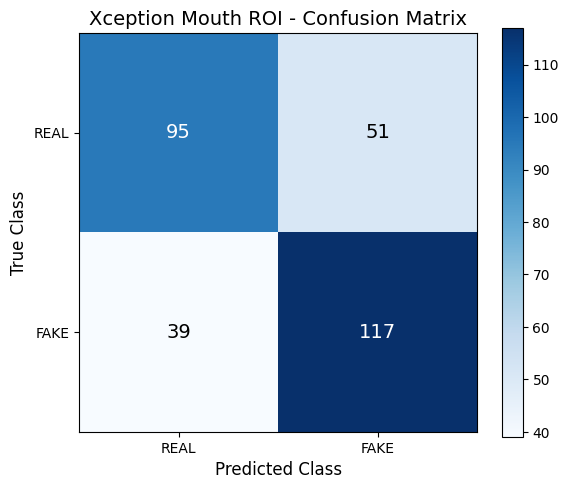

✓ Confusion Matrix kaydedildi.

2/6 - ROC CURVE


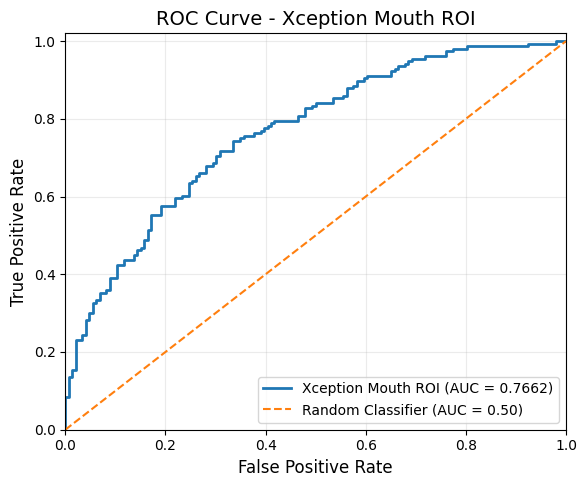

✓ ROC Curve kaydedildi. AUC = 0.7662

3/6 - FROZEN TRAINING CURVES


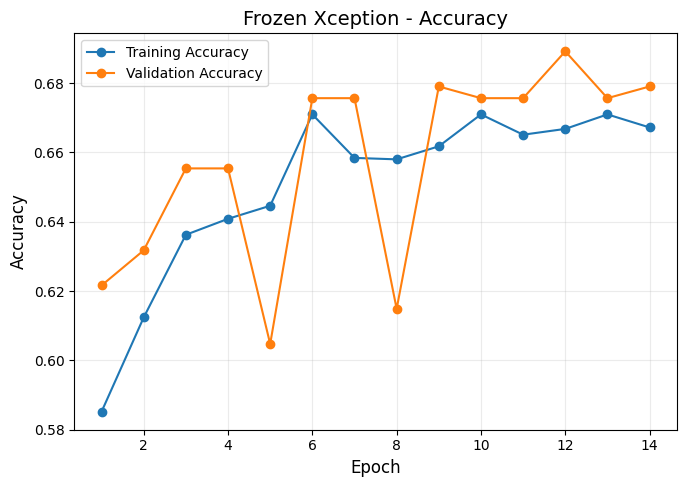

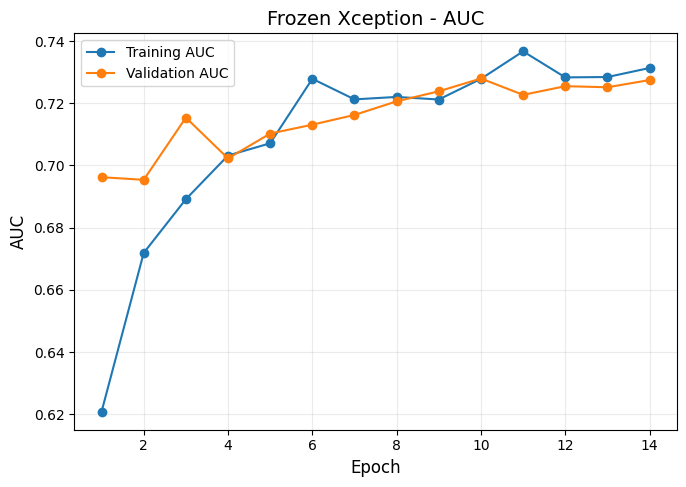

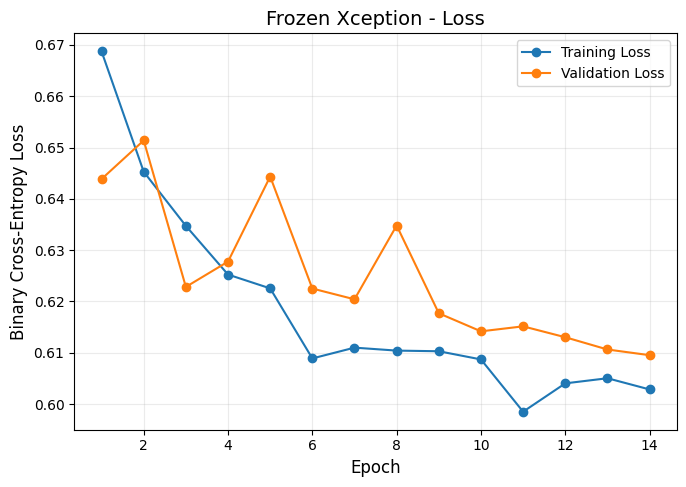

✓ Frozen training grafikleri oluşturuldu.

4/6 - FINE-TUNING CURVES


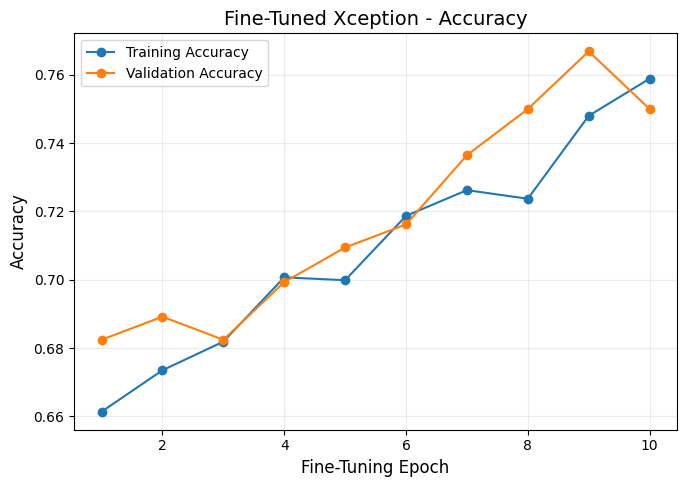

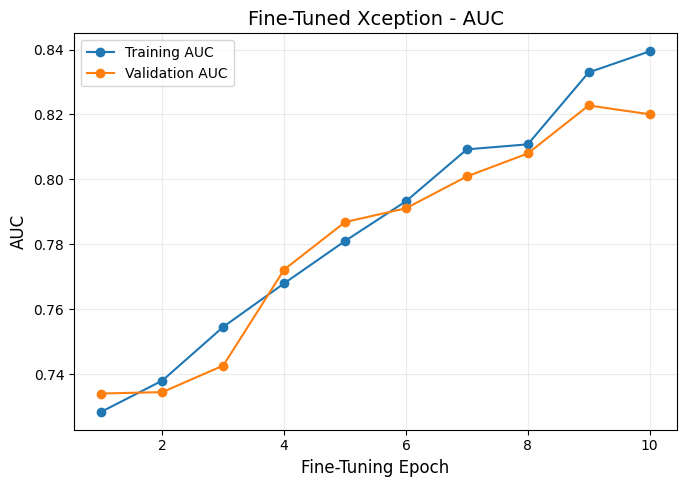

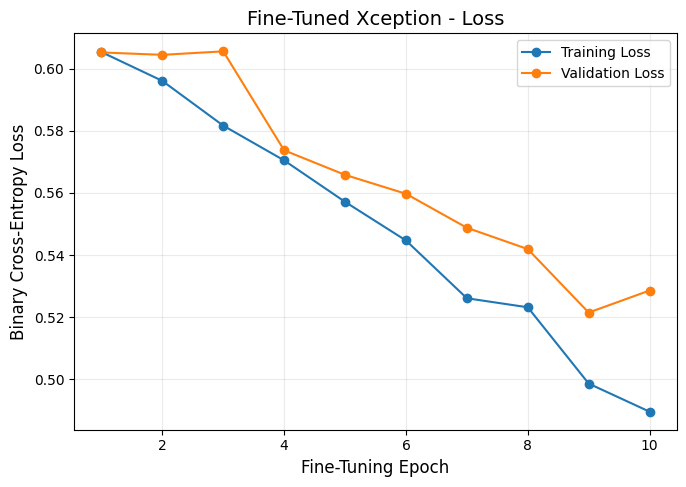

✓ Fine-tuning grafikleri oluşturuldu.

5/6 - FROZEN VS FINE-TUNED


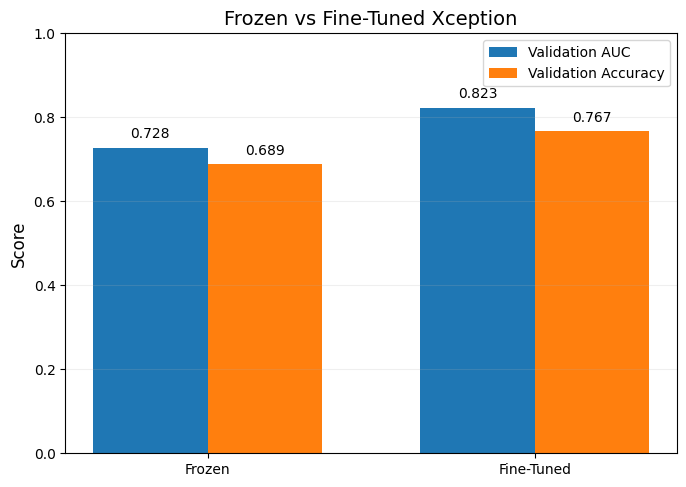

✓ Frozen vs Fine-Tuned karşılaştırması oluşturuldu.

6/6 - FINAL TEST METRICS


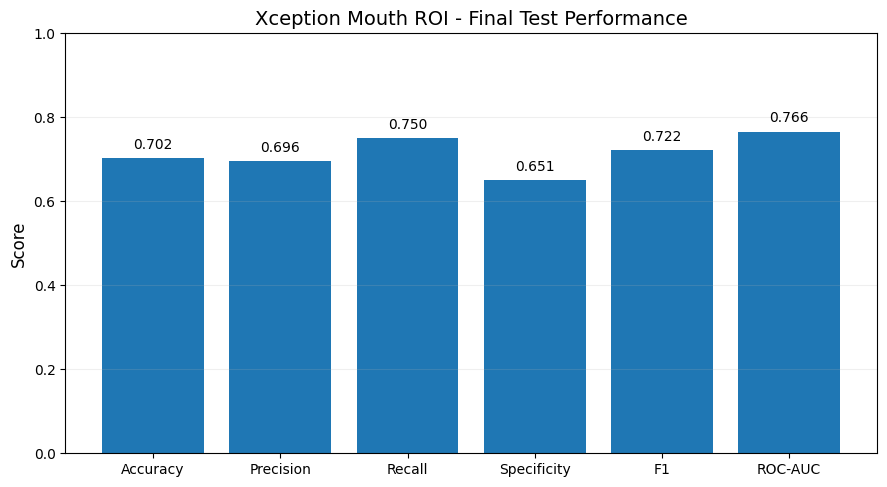

✓ Final test metric grafiği oluşturuldu.

✓ CELL 11 BAŞARIYLA TAMAMLANDI
✓ Toplam PNG grafik sayısı: 10
✓ Grafik çözünürlüğü: 600 DPI
✓ Confusion Matrix oluşturuldu.
✓ ROC Curve oluşturuldu.
✓ Frozen training grafikleri oluşturuldu.
✓ Fine-tuning grafikleri oluşturuldu.
✓ Frozen vs Fine-Tuned karşılaştırması oluşturuldu.
✓ Final test metric grafiği oluşturuldu.

Grafiklerin kaydedildiği klasör:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/xception_experiment/results/figures

✓ Sonraki ve SON aşama: CELL 12


In [11]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# CELL 11 - VISUALIZATION & REPORT FIGURES
# ==========================================================
#
# Bu hücre:
#
# 1) Confusion Matrix
# 2) ROC Curve
# 3) Frozen Training Curves
# 4) Fine-Tuning Training Curves
# 5) Frozen vs Fine-Tuned Validation Comparison
# 6) Final Test Metrics Bar Chart
#
# oluşturur.
#
# Tüm grafikler:
#       PNG
#       600 DPI
#
# olarak Drive'a kaydedilir.
#
# MODEL EĞİTİMİ YAPILMAZ.
# ==========================================================


# ==========================================================
# 1. IMPORTS
# ==========================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc
)


print("=" * 75)
print("XCEPTION - REPORT FIGURES")
print("=" * 75)


# ==========================================================
# 2. GEREKLİ DEĞİŞKENLERİ KONTROL ET
# ==========================================================

required_variables = [
    "y_true",
    "y_pred",
    "test_probabilities",
    "RESULTS_DIR"
]


missing_variables = [

    variable_name

    for variable_name in required_variables

    if variable_name not in globals()
]


if len(missing_variables) > 0:

    raise NameError(
        "Eksik değişkenler: "
        + ", ".join(missing_variables)
        + "\nÖnce Cell 9 ve Cell 10'u çalıştır."
    )


# ==========================================================
# 3. FIGURES KLASÖRÜ
# ==========================================================

FIGURES_DIR = (
    RESULTS_DIR
    / "figures"
)


FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "\nGrafik klasörü:"
)

print(
    FIGURES_DIR
)


print(
    "\n✓ Grafik klasörü hazır."
)


# ==========================================================
# 4. GENEL GRAFİK AYARLARI
# ==========================================================

plt.rcParams.update({

    "font.size": 11,

    "axes.titlesize": 14,

    "axes.labelsize": 12,

    "xtick.labelsize": 10,

    "ytick.labelsize": 10,

    "legend.fontsize": 10,

    "figure.titlesize": 15
})


# ==========================================================
# 5. CONFUSION MATRIX
# ==========================================================

print("\n" + "=" * 75)
print("1/6 - CONFUSION MATRIX")
print("=" * 75)


cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ]
)


fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


im = ax.imshow(
    cm,
    cmap="Blues"
)


ax.set_title(
    "Xception Mouth ROI - Confusion Matrix"
)


ax.set_xlabel(
    "Predicted Class"
)


ax.set_ylabel(
    "True Class"
)


ax.set_xticks(
    [
        0,
        1
    ]
)


ax.set_yticks(
    [
        0,
        1
    ]
)


ax.set_xticklabels(
    [
        "REAL",
        "FAKE"
    ]
)


ax.set_yticklabels(
    [
        "REAL",
        "FAKE"
    ]
)


# Hücre sayılarını yaz
threshold = (
    cm.max()
    / 2
)


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        ax.text(

            j,
            i,

            str(
                cm[i, j]
            ),

            ha="center",
            va="center",

            fontsize=14,

            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


fig.colorbar(
    im,
    ax=ax
)


plt.tight_layout()


CONFUSION_MATRIX_PATH = (
    FIGURES_DIR
    / "01_confusion_matrix.png"
)


plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=600,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    "✓ Confusion Matrix kaydedildi."
)


# ==========================================================
# 6. ROC CURVE
# ==========================================================

print("\n" + "=" * 75)
print("2/6 - ROC CURVE")
print("=" * 75)


fpr, tpr, roc_thresholds = roc_curve(

    y_true,

    test_probabilities
)


roc_auc_value = auc(
    fpr,
    tpr
)


fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


ax.plot(

    fpr,
    tpr,

    linewidth=2,

    label=(
        f"Xception Mouth ROI "
        f"(AUC = {roc_auc_value:.4f})"
    )
)


# Random classifier çizgisi
ax.plot(

    [
        0,
        1
    ],

    [
        0,
        1
    ],

    linestyle="--",

    linewidth=1.5,

    label="Random Classifier (AUC = 0.50)"
)


ax.set_xlim(
    [
        0,
        1
    ]
)


ax.set_ylim(
    [
        0,
        1.02
    ]
)


ax.set_xlabel(
    "False Positive Rate"
)


ax.set_ylabel(
    "True Positive Rate"
)


ax.set_title(
    "ROC Curve - Xception Mouth ROI"
)


ax.grid(
    alpha=0.25
)


ax.legend(
    loc="lower right"
)


plt.tight_layout()


ROC_CURVE_PATH = (
    FIGURES_DIR
    / "02_roc_curve.png"
)


plt.savefig(
    ROC_CURVE_PATH,
    dpi=600,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    f"✓ ROC Curve kaydedildi. "
    f"AUC = {roc_auc_value:.4f}"
)


# ==========================================================
# 7. FROZEN TRAINING HISTORY
# ==========================================================

print("\n" + "=" * 75)
print("3/6 - FROZEN TRAINING CURVES")
print("=" * 75)


FROZEN_HISTORY_PATH = (
    RESULTS_DIR
    / "frozen_training_history.csv"
)


if FROZEN_HISTORY_PATH.exists():

    frozen_history = pd.read_csv(
        FROZEN_HISTORY_PATH
    )


    epochs_frozen = np.arange(
        1,
        len(frozen_history) + 1
    )


    # ------------------------------------------------------
    # FROZEN ACCURACY
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "accuracy"
        ],

        marker="o",

        label="Training Accuracy"
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "val_accuracy"
        ],

        marker="o",

        label="Validation Accuracy"
    )


    ax.set_xlabel(
        "Epoch"
    )


    ax.set_ylabel(
        "Accuracy"
    )


    ax.set_title(
        "Frozen Xception - Accuracy"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "03_frozen_accuracy.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    # ------------------------------------------------------
    # FROZEN AUC
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "auc"
        ],

        marker="o",

        label="Training AUC"
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "val_auc"
        ],

        marker="o",

        label="Validation AUC"
    )


    ax.set_xlabel(
        "Epoch"
    )


    ax.set_ylabel(
        "AUC"
    )


    ax.set_title(
        "Frozen Xception - AUC"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "04_frozen_auc.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    # ------------------------------------------------------
    # FROZEN LOSS
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "loss"
        ],

        marker="o",

        label="Training Loss"
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "val_loss"
        ],

        marker="o",

        label="Validation Loss"
    )


    ax.set_xlabel(
        "Epoch"
    )


    ax.set_ylabel(
        "Binary Cross-Entropy Loss"
    )


    ax.set_title(
        "Frozen Xception - Loss"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "05_frozen_loss.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    print(
        "✓ Frozen training grafikleri oluşturuldu."
    )


else:

    print(
        "⚠ frozen_training_history.csv bulunamadı."
    )


# ==========================================================
# 8. FINE-TUNING HISTORY
# ==========================================================

print("\n" + "=" * 75)
print("4/6 - FINE-TUNING CURVES")
print("=" * 75)


FINETUNE_HISTORY_PATH = (
    RESULTS_DIR
    / "finetune_training_history.csv"
)


if FINETUNE_HISTORY_PATH.exists():

    finetune_history = pd.read_csv(
        FINETUNE_HISTORY_PATH
    )


    epochs_finetune = np.arange(
        1,
        len(finetune_history) + 1
    )


    # ------------------------------------------------------
    # FINE-TUNING ACCURACY
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "accuracy"
        ],

        marker="o",

        label="Training Accuracy"
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "val_accuracy"
        ],

        marker="o",

        label="Validation Accuracy"
    )


    ax.set_xlabel(
        "Fine-Tuning Epoch"
    )


    ax.set_ylabel(
        "Accuracy"
    )


    ax.set_title(
        "Fine-Tuned Xception - Accuracy"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "06_finetune_accuracy.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    # ------------------------------------------------------
    # FINE-TUNING AUC
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "auc"
        ],

        marker="o",

        label="Training AUC"
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "val_auc"
        ],

        marker="o",

        label="Validation AUC"
    )


    ax.set_xlabel(
        "Fine-Tuning Epoch"
    )


    ax.set_ylabel(
        "AUC"
    )


    ax.set_title(
        "Fine-Tuned Xception - AUC"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "07_finetune_auc.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    # ------------------------------------------------------
    # FINE-TUNING LOSS
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "loss"
        ],

        marker="o",

        label="Training Loss"
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "val_loss"
        ],

        marker="o",

        label="Validation Loss"
    )


    ax.set_xlabel(
        "Fine-Tuning Epoch"
    )


    ax.set_ylabel(
        "Binary Cross-Entropy Loss"
    )


    ax.set_title(
        "Fine-Tuned Xception - Loss"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "08_finetune_loss.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    print(
        "✓ Fine-tuning grafikleri oluşturuldu."
    )


else:

    print(
        "⚠ finetune_training_history.csv bulunamadı."
    )


# ==========================================================
# 9. FROZEN VS FINE-TUNED VALIDATION PERFORMANCE
# ==========================================================

print("\n" + "=" * 75)
print("5/6 - FROZEN VS FINE-TUNED")
print("=" * 75)


FROZEN_SUMMARY_PATH = (
    RESULTS_DIR
    / "frozen_training_summary.json"
)


FINETUNE_SUMMARY_PATH = (
    RESULTS_DIR
    / "finetune_training_summary.json"
)


if (
    FROZEN_SUMMARY_PATH.exists()
    and
    FINETUNE_SUMMARY_PATH.exists()
):


    with open(
        FROZEN_SUMMARY_PATH,
        "r",
        encoding="utf-8"
    ) as file:

        frozen_summary = json.load(
            file
        )


    with open(
        FINETUNE_SUMMARY_PATH,
        "r",
        encoding="utf-8"
    ) as file:

        finetune_summary = json.load(
            file
        )


    frozen_auc = float(
        frozen_summary[
            "best_validation_auc"
        ]
    )


    finetune_auc = float(
        finetune_summary[
            "best_validation_auc"
        ]
    )


    frozen_acc = float(
        frozen_summary[
            "best_validation_accuracy"
        ]
    )


    finetune_acc = float(
        finetune_summary[
            "best_validation_accuracy"
        ]
    )


    stages = [
        "Frozen",
        "Fine-Tuned"
    ]


    auc_values = [
        frozen_auc,
        finetune_auc
    ]


    accuracy_values = [
        frozen_acc,
        finetune_acc
    ]


    x = np.arange(
        len(stages)
    )


    width = 0.35


    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    bars_auc = ax.bar(

        x - width / 2,

        auc_values,

        width,

        label="Validation AUC"
    )


    bars_acc = ax.bar(

        x + width / 2,

        accuracy_values,

        width,

        label="Validation Accuracy"
    )


    ax.set_ylabel(
        "Score"
    )


    ax.set_ylim(
        0,
        1
    )


    ax.set_xticks(
        x
    )


    ax.set_xticklabels(
        stages
    )


    ax.set_title(
        "Frozen vs Fine-Tuned Xception"
    )


    ax.legend()


    ax.grid(
        axis="y",
        alpha=0.20
    )


    # Sayıları barların üzerine yaz
    for bars in [
        bars_auc,
        bars_acc
    ]:

        for bar in bars:

            height = bar.get_height()

            ax.text(

                bar.get_x()
                +
                bar.get_width() / 2,

                height + 0.015,

                f"{height:.3f}",

                ha="center",
                va="bottom",

                fontsize=10
            )


    plt.tight_layout()


    COMPARISON_PATH = (
        FIGURES_DIR
        / "09_frozen_vs_finetuned.png"
    )


    plt.savefig(
        COMPARISON_PATH,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    print(
        "✓ Frozen vs Fine-Tuned karşılaştırması oluşturuldu."
    )


else:

    print(
        "⚠ Training summary dosyaları bulunamadı."
    )


# ==========================================================
# 10. FINAL TEST METRICS BAR CHART
# ==========================================================

print("\n" + "=" * 75)
print("6/6 - FINAL TEST METRICS")
print("=" * 75)


# Cell 10'dan gelen metrikleri kullanıyoruz.

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC-AUC"
]


metric_values = [
    float(accuracy),
    float(precision),
    float(recall),
    float(specificity),
    float(f1),
    float(roc_auc)
]


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)


bars = ax.bar(
    metric_names,
    metric_values
)


ax.set_ylim(
    0,
    1
)


ax.set_ylabel(
    "Score"
)


ax.set_title(
    "Xception Mouth ROI - Final Test Performance"
)


ax.grid(
    axis="y",
    alpha=0.20
)


# Değerleri barların üzerine yaz

for bar, value in zip(
    bars,
    metric_values
):

    ax.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        value + 0.015,

        f"{value:.3f}",

        ha="center",
        va="bottom",

        fontsize=10
    )


plt.tight_layout()


FINAL_METRICS_FIGURE_PATH = (
    FIGURES_DIR
    / "10_final_test_metrics.png"
)


plt.savefig(
    FINAL_METRICS_FIGURE_PATH,
    dpi=600,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    "✓ Final test metric grafiği oluşturuldu."
)


# ==========================================================
# 11. FIGURE MANIFEST
# ==========================================================
#
# Hangi grafiklerin oluşturulduğunu kaydediyoruz.


figure_files = sorted(

    [
        file.name

        for file in FIGURES_DIR.glob(
            "*.png"
        )
    ]
)


figure_manifest = {

    "region":
        "mouth",

    "model":
        "Xception",

    "dpi":
        600,

    "figure_count":
        len(
            figure_files
        ),

    "figures":
        figure_files
}


FIGURE_MANIFEST_PATH = (
    RESULTS_DIR
    / "figure_manifest.json"
)


with open(
    FIGURE_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        figure_manifest,
        file,
        ensure_ascii=False,
        indent=4
    )


# ==========================================================
# 12. SONUÇ
# ==========================================================

print("\n" + "=" * 75)

print(
    "✓ CELL 11 BAŞARIYLA TAMAMLANDI"
)

print(
    f"✓ Toplam PNG grafik sayısı: "
    f"{len(figure_files)}"
)

print(
    "✓ Grafik çözünürlüğü: 600 DPI"
)

print(
    "✓ Confusion Matrix oluşturuldu."
)

print(
    "✓ ROC Curve oluşturuldu."
)

print(
    "✓ Frozen training grafikleri oluşturuldu."
)

print(
    "✓ Fine-tuning grafikleri oluşturuldu."
)

print(
    "✓ Frozen vs Fine-Tuned karşılaştırması oluşturuldu."
)

print(
    "✓ Final test metric grafiği oluşturuldu."
)

print(
    "\nGrafiklerin kaydedildiği klasör:"
)

print(
    FIGURES_DIR
)

print(
    "\n✓ Sonraki ve SON aşama: CELL 12"
)

print("=" * 75)

In [12]:
# ==========================================================
# MOUTH DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# CELL 12 - FINAL EXPORT & EXPERIMENT SUMMARY
# ==========================================================
#
# BU SON HÜCREDİR.
#
# Bu hücre:
#
# 1) Nihai Sonuçlar klasörünü oluşturur.
# 2) En iyi Xception modelini kopyalar.
# 3) Test sonuçlarını kopyalar.
# 4) Training / fine-tuning özetlerini kopyalar.
# 5) 600 DPI grafiklerin tamamını kopyalar.
# 6) Deneyin okunabilir final özetini TXT olarak oluşturur.
# 7) Deney bilgilerini JSON olarak kaydeder.
#
# MODEL YENİDEN EĞİTİLMEZ.
# ==========================================================


# ==========================================================
# 1. IMPORTLAR
# ==========================================================

import json
import shutil

from pathlib import Path

import numpy as np
import pandas as pd


print("=" * 80)
print("XCEPTION MOUTH DEEPFAKE - FINAL EXPORT")
print("=" * 80)


# ==========================================================
# 2. KULLANICININ BELİRLEDİĞİ FİNAL DRIVE YOLU
# ==========================================================

FINAL_RESULTS_ROOT = Path(
    "/content/drive/MyDrive/"
    "AISC Çalışmalar/"
    "Deneyler/"
    "Dilara/"
    "Deney 1/"
    "Sonuçlar"
)


# ==========================================================
# 3. XCEPTION İÇİN AYRI KLASÖR
# ==========================================================
#
# İleride başka modeller de Sonuçlar klasörüne eklenebilir.
#
# Örneğin:
#
# Sonuçlar/
# ├── Xception_Mouth/
# ├── DenseNet121_Mouth/
# ├── HOG_LBP_SVM/
# └── ...
#
# Böylece deneyler birbirine karışmaz.


FINAL_XCEPTION_ROOT = (
    FINAL_RESULTS_ROOT
    / "Xception_Mouth"
)


FINAL_MODEL_DIR = (
    FINAL_XCEPTION_ROOT
    / "model"
)


FINAL_METRICS_DIR = (
    FINAL_XCEPTION_ROOT
    / "metrics"
)


FINAL_FIGURES_DIR = (
    FINAL_XCEPTION_ROOT
    / "figures"
)


FINAL_LOGS_DIR = (
    FINAL_XCEPTION_ROOT
    / "training_logs"
)


FINAL_PREDICTIONS_DIR = (
    FINAL_XCEPTION_ROOT
    / "predictions"
)


FINAL_SUMMARY_DIR = (
    FINAL_XCEPTION_ROOT
    / "summary"
)


# ==========================================================
# 4. KLASÖRLERİ OLUŞTUR
# ==========================================================

for folder in [

    FINAL_XCEPTION_ROOT,
    FINAL_MODEL_DIR,
    FINAL_METRICS_DIR,
    FINAL_FIGURES_DIR,
    FINAL_LOGS_DIR,
    FINAL_PREDICTIONS_DIR,
    FINAL_SUMMARY_DIR

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


print("\n✓ Final klasör yapısı oluşturuldu.")


# ==========================================================
# 5. FİNAL MODELİ BELİRLE
# ==========================================================
#
# Cell 9'da validation AUC üzerinden seçilen modeli
# kullanıyoruz.
#
# Bizim deneyimizde büyük ihtimalle:
#
# best_xception_finetuned.keras
#
# seçilmiş durumda.


if "SELECTED_MODEL_PATH" not in globals():

    # Cell 9 değişkeni yoksa kayıtlı sonuçlardan otomatik
    # fine-tuned modeli kullan.
    SELECTED_MODEL_PATH = (
        MODEL_DIR
        / "best_xception_finetuned.keras"
    )


SELECTED_MODEL_PATH = Path(
    SELECTED_MODEL_PATH
)


if not SELECTED_MODEL_PATH.exists():

    raise FileNotFoundError(
        f"Nihai model bulunamadı:\n"
        f"{SELECTED_MODEL_PATH}"
    )


# ==========================================================
# 6. MODELİ FİNAL KLASÖRE KOPYALA
# ==========================================================

FINAL_MODEL_PATH = (
    FINAL_MODEL_DIR
    / "Xception_Mouth_Final.keras"
)


shutil.copy2(
    SELECTED_MODEL_PATH,
    FINAL_MODEL_PATH
)


print(
    "\n✓ Final model kopyalandı:"
)

print(
    FINAL_MODEL_PATH
)


# ==========================================================
# 7. METRİK DOSYALARINI KOPYALA
# ==========================================================

metric_files = [

    "final_test_metrics.json",
    "final_test_metrics.csv",
    "classification_report.txt",
    "model_selection_and_test_summary.json"

]


for file_name in metric_files:

    source = (
        RESULTS_DIR
        / file_name
    )

    destination = (
        FINAL_METRICS_DIR
        / file_name
    )


    if source.exists():

        shutil.copy2(
            source,
            destination
        )

        print(
            f"✓ Metric: {file_name}"
        )

    else:

        print(
            f"⚠ Bulunamadı: {file_name}"
        )


# ==========================================================
# 8. TEST TAHMİNLERİNİ KOPYALA
# ==========================================================

TEST_PREDICTIONS_SOURCE = (
    RESULTS_DIR
    / "test_predictions.csv"
)


if TEST_PREDICTIONS_SOURCE.exists():

    shutil.copy2(

        TEST_PREDICTIONS_SOURCE,

        FINAL_PREDICTIONS_DIR
        / "test_predictions.csv"
    )


    print(
        "✓ test_predictions.csv kopyalandı."
    )


# ==========================================================
# 9. TRAINING LOG DOSYALARINI KOPYALA
# ==========================================================

training_log_files = [

    "frozen_training_log.csv",
    "frozen_training_history.csv",
    "frozen_training_summary.json",

    "finetune_training_log.csv",
    "finetune_training_history.csv",
    "finetune_training_summary.json",

    "augmentation_config.json",
    "xception_model_config.json"

]


for file_name in training_log_files:

    source = (
        RESULTS_DIR
        / file_name
    )

    destination = (
        FINAL_LOGS_DIR
        / file_name
    )


    if source.exists():

        shutil.copy2(
            source,
            destination
        )

        print(
            f"✓ Training log: {file_name}"
        )


# ==========================================================
# 10. TÜM 600 DPI GRAFİKLERİ KOPYALA
# ==========================================================

source_figures_dir = (
    RESULTS_DIR
    / "figures"
)


copied_figure_count = 0


if source_figures_dir.exists():

    for figure_path in sorted(
        source_figures_dir.glob(
            "*.png"
        )
    ):

        shutil.copy2(

            figure_path,

            FINAL_FIGURES_DIR
            / figure_path.name
        )


        copied_figure_count += 1


print(
    f"\n✓ Kopyalanan grafik sayısı: "
    f"{copied_figure_count}"
)


# ==========================================================
# 11. SONUÇLARI DEĞİŞKENLERDEN / JSON'DAN AL
# ==========================================================

FINAL_METRICS_SOURCE = (
    RESULTS_DIR
    / "final_test_metrics.json"
)


with open(
    FINAL_METRICS_SOURCE,
    "r",
    encoding="utf-8"
) as file:

    metrics_data = json.load(
        file
    )


# ==========================================================
# 12. TRAINING SUMMARY DOSYALARINI OKU
# ==========================================================

FROZEN_SUMMARY_SOURCE = (
    RESULTS_DIR
    / "frozen_training_summary.json"
)


FINETUNE_SUMMARY_SOURCE = (
    RESULTS_DIR
    / "finetune_training_summary.json"
)


with open(
    FROZEN_SUMMARY_SOURCE,
    "r",
    encoding="utf-8"
) as file:

    frozen_data = json.load(
        file
    )


with open(
    FINETUNE_SUMMARY_SOURCE,
    "r",
    encoding="utf-8"
) as file:

    finetune_data = json.load(
        file
    )


# ==========================================================
# 13. DENEY BİLGİLERİ
# ==========================================================

final_experiment_data = {

    "experiment_name":
        "Xception Mouth ROI Deepfake Detection",

    "region":
        "mouth",

    "model":
        "Xception",

    "pretrained_weights":
        "ImageNet",

    "input_size":
        [
            224,
            224,
            3
        ],

    "class_mapping": {
        "REAL": 0,
        "FAKE": 1
    },

    "dataset": {

        "initial_frames":
            3000,

        "valid_mouth_roi":
            2987,

        "train_roi":
            2389,

        "validation_roi":
            296,

        "test_roi":
            302,

        "test_real":
            146,

        "test_fake":
            156
    },

    "training": {

        "frozen_best_validation_auc":
            frozen_data[
                "best_validation_auc"
            ],

        "frozen_best_validation_accuracy":
            frozen_data[
                "best_validation_accuracy"
            ],

        "frozen_training_minutes":
            frozen_data[
                "training_minutes"
            ],

        "fine_tuned_best_validation_auc":
            finetune_data[
                "best_validation_auc"
            ],

        "fine_tuned_best_validation_accuracy":
            finetune_data[
                "best_validation_accuracy"
            ],

        "fine_tuning_minutes":
            finetune_data[
                "training_minutes"
            ]
    },

    "final_test": {

        "accuracy":
            metrics_data[
                "accuracy"
            ],

        "balanced_accuracy":
            metrics_data[
                "balanced_accuracy"
            ],

        "precision_fake":
            metrics_data[
                "precision_fake"
            ],

        "recall_fake":
            metrics_data[
                "recall_fake"
            ],

        "specificity":
            metrics_data[
                "specificity"
            ],

        "f1_score_fake":
            metrics_data[
                "f1_score_fake"
            ],

        "roc_auc":
            metrics_data[
                "roc_auc"
            ],

        "confusion_matrix":
            metrics_data[
                "confusion_matrix"
            ]
    },

    "final_model_path":
        str(
            FINAL_MODEL_PATH
        ),

    "figures_directory":
        str(
            FINAL_FIGURES_DIR
        ),

    "figure_count":
        copied_figure_count
}


# ==========================================================
# 14. FINAL JSON KAYDET
# ==========================================================

FINAL_EXPERIMENT_JSON_PATH = (
    FINAL_SUMMARY_DIR
    / "Xception_Mouth_Final_Experiment.json"
)


with open(
    FINAL_EXPERIMENT_JSON_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(

        final_experiment_data,

        file,

        ensure_ascii=False,

        indent=4
    )


print(
    "\n✓ Final experiment JSON oluşturuldu."
)


# ==========================================================
# 15. OKUNABİLİR TXT RAPOR ÖZETİ
# ==========================================================

cm_data = metrics_data[
    "confusion_matrix"
]


summary_text = f"""
============================================================
XCEPTION MOUTH ROI DEEPFAKE DETECTION
FINAL EXPERIMENT SUMMARY
============================================================

1. EXPERIMENT

Region                  : Mouth
Model                   : Xception
Pretrained weights      : ImageNet
Input size              : 224 x 224 x 3
Task                    : Binary Classification
Class mapping           : REAL = 0, FAKE = 1


2. DATASET

Initial frames          : 3000
Valid Mouth ROI         : 2987

Train ROI               : 2389
Validation ROI          : 296
Test ROI                : 302

Test REAL               : 146
Test FAKE               : 156


3. FROZEN BACKBONE TRAINING

Best Validation AUC     : {frozen_data["best_validation_auc"]:.4f}
Best Validation Acc.    : {frozen_data["best_validation_accuracy"]:.4f}
Training Time           : {frozen_data["training_minutes"]:.2f} minutes


4. FINE-TUNING

Best Validation AUC     : {finetune_data["best_validation_auc"]:.4f}
Best Validation Acc.    : {finetune_data["best_validation_accuracy"]:.4f}
Fine-Tuning Time        : {finetune_data["training_minutes"]:.2f} minutes


5. FINAL TEST PERFORMANCE

Accuracy                : {metrics_data["accuracy"]:.4f}
Balanced Accuracy       : {metrics_data["balanced_accuracy"]:.4f}

Precision (FAKE)        : {metrics_data["precision_fake"]:.4f}
Recall / Sensitivity    : {metrics_data["recall_fake"]:.4f}
Specificity             : {metrics_data["specificity"]:.4f}

F1 Score (FAKE)         : {metrics_data["f1_score_fake"]:.4f}
ROC-AUC                 : {metrics_data["roc_auc"]:.4f}


6. CONFUSION MATRIX

True Negative (TN)      : {cm_data["true_negative"]}
False Positive (FP)     : {cm_data["false_positive"]}
False Negative (FN)     : {cm_data["false_negative"]}
True Positive (TP)      : {cm_data["true_positive"]}


7. INTERPRETATION

Frozen Xception validation AUC:
{frozen_data["best_validation_auc"]:.4f}

Fine-tuned Xception validation AUC:
{finetune_data["best_validation_auc"]:.4f}

Fine-tuning improved validation discrimination performance.

On the independent test set, the final model achieved:

Accuracy:
{metrics_data["accuracy"] * 100:.2f}%

FAKE Recall:
{metrics_data["recall_fake"] * 100:.2f}%

ROC-AUC:
{metrics_data["roc_auc"]:.4f}

The model showed stronger sensitivity for detecting FAKE samples
than specificity for correctly identifying REAL samples.


8. OUTPUTS

Final model:
{FINAL_MODEL_PATH}

Metrics:
{FINAL_METRICS_DIR}

Predictions:
{FINAL_PREDICTIONS_DIR}

Training Logs:
{FINAL_LOGS_DIR}

600 DPI Figures:
{FINAL_FIGURES_DIR}


============================================================
END OF EXPERIMENT
============================================================
"""


FINAL_SUMMARY_TXT_PATH = (
    FINAL_SUMMARY_DIR
    / "Xception_Mouth_Final_Summary.txt"
)


with open(
    FINAL_SUMMARY_TXT_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        summary_text
    )


print(
    "✓ Final TXT deney özeti oluşturuldu."
)


# ==========================================================
# 16. FINAL KLASÖR İÇERİĞİNİ KONTROL ET
# ==========================================================

print("\n" + "=" * 80)
print("FINAL OUTPUT STRUCTURE")
print("=" * 80)


print(
    FINAL_XCEPTION_ROOT
)


print(
    "\n├── model"
)

print(
    "├── metrics"
)

print(
    "├── figures"
)

print(
    "├── training_logs"
)

print(
    "├── predictions"
)

print(
    "└── summary"
)


# ==========================================================
# 17. FİNAL SONUÇ ÖZETİ
# ==========================================================

print("\n" + "=" * 80)
print("FINAL TEST RESULT")
print("=" * 80)


print(
    f"Accuracy    : "
    f"{metrics_data['accuracy'] * 100:.2f}%"
)


print(
    f"Precision   : "
    f"{metrics_data['precision_fake'] * 100:.2f}%"
)


print(
    f"Recall      : "
    f"{metrics_data['recall_fake'] * 100:.2f}%"
)


print(
    f"Specificity : "
    f"{metrics_data['specificity'] * 100:.2f}%"
)


print(
    f"F1 Score    : "
    f"{metrics_data['f1_score_fake']:.4f}"
)


print(
    f"ROC-AUC     : "
    f"{metrics_data['roc_auc']:.4f}"
)


# ==========================================================
# 18. CELL SONUCU
# ==========================================================

print("\n" + "=" * 80)

print(
    "✓ CELL 12 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ XCEPTION MOUTH DENEYİ TAMAMLANDI."
)

print(
    "✓ Final model kaydedildi."
)

print(
    "✓ Test metrikleri kaydedildi."
)

print(
    "✓ Test tahminleri kaydedildi."
)

print(
    "✓ Training logları kaydedildi."
)

print(
    "✓ 600 DPI grafikler kaydedildi."
)

print(
    "✓ Final JSON deney özeti kaydedildi."
)

print(
    "✓ Final TXT deney özeti kaydedildi."
)


print(
    "\nNihai sonuç klasörü:"
)

print(
    FINAL_XCEPTION_ROOT
)


print("=" * 80)

XCEPTION MOUTH DEEPFAKE - FINAL EXPORT

✓ Final klasör yapısı oluşturuldu.

✓ Final model kopyalandı:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Sonuçlar/Xception_Mouth/model/Xception_Mouth_Final.keras
✓ Metric: final_test_metrics.json
✓ Metric: final_test_metrics.csv
✓ Metric: classification_report.txt
✓ Metric: model_selection_and_test_summary.json
✓ test_predictions.csv kopyalandı.
✓ Training log: frozen_training_log.csv
✓ Training log: frozen_training_history.csv
✓ Training log: frozen_training_summary.json
✓ Training log: finetune_training_log.csv
✓ Training log: finetune_training_history.csv
✓ Training log: finetune_training_summary.json
✓ Training log: augmentation_config.json
✓ Training log: xception_model_config.json

✓ Kopyalanan grafik sayısı: 10

✓ Final experiment JSON oluşturuldu.
✓ Final TXT deney özeti oluşturuldu.

FINAL OUTPUT STRUCTURE
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Sonuçlar/Xception_Mouth

├── model
├── metri